# Generate data, lesioning stim-tuned neurons

firing rates, LFP, behavior

run after filtering down the models using filter_models_multiload.ipynb (in 0_behavior/1_model_performance folder)  

APPLY TO MULTIPLE MODELS
1. find neurons that are stim-tuned
2. for each stimulus tuning (ie 0, 1, 2, 3):
    1. lesion outgoing connections by 50% for those neurons preferring that stimulus
    2. generate data for a specific combo of trials, taking into account the preferred stimulus
3. study performance

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-06-29 16:03:52.250140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 16:03:52.258173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-29 16:03:52.267026: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-29 16:03:52.269707: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-29 16:03:52.276886: I tensorflow/core/platform/cpu_feature_guar

## delay=150, lesion all stim-selective

In [2]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

### necessary functions

In [3]:
def generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, max_load):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=1
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    if incl_pref:
        stim_chan_idx = [pref]
    else:
        # choose a random channel that is not the preferred channel
        stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False)
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [4]:
def generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos, match, match_pref=None, max_load=3):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # pref_pos is the index of the stimulus number to put the preferred channel
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=3
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    # choose channels to activate
    stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False) # random channels that are not the preferred channel
    if incl_pref:
        # replace the specified stim position with the preferred channel
        stim_chan_idx[pref_pos] = pref
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        if (incl_pref==1) and (match_pref is not None): # for match trials with pref shown as a stim
            if match_pref: # probe should be the preferred stim
                match_chan_idx = pref
            else: # probe is not the preferred stim
                non_pref_stims = np.setdiff1d(stim_chan_idx, pref)
                match_chan_idx = int(np.random.choice(non_pref_stims, 1)[0])
        else:
            match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [5]:
# function version without plotting

def generate_stimset(pref, settings):
    
    # generate load-1 first
    load = 1
    n_trials = 20
    u_all = []
    trial_type_all = []
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for i in range(n_trials):
                u, label, stim_ids = generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, 
                                                                        max_load=3)
                u_all.append(u)
                trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                
    # now load-3
    match_pref=None
    load = 3
    n_trials = 10
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for pref_pos in [0, 1, 2]:
                for i in range(n_trials):
                    if match == 1 & incl_pref == 1:
                        # for half of trials, use the preferred channel for the match
                        if i < n_trials // 2:
                            match_pref = True
                        else:
                            match_pref = False
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, match_pref=match_pref, max_load=3)
                    else:
                        match_pref=None
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, max_load=3)
                    u_all.append(u)
                    trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                    
    return np.array(u_all), np.array(trial_type_all)

## lesion by 50%

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [6]:
u_all, trial_type_all = generate_stimset(pref=0, settings=settings)

print("u_all shape:", u_all.shape)
print("trial_type_all shape:", trial_type_all.shape)

u_all shape: (200, 4, 450)
trial_type_all shape: (200, 6)


In [7]:
for model_name in model_names:
    
    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]
    stim_tuning = stim1_stimtuning[stim_selective]
    
    unique_stims = np.unique(stim_tuning)
    for stim in unique_stims: # 0, 1, 2, 3
        neuron_idxs = stim_selective[stim_tuning == stim] # neuron indices for this specific stimulus
        u_all, trial_type_all = generate_stimset(pref=int(stim), settings=settings)

        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0.5,
            lesion_tag=f"stim_stimpref_{stim:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

### analyze behavioral data

#### necessary functions

In [7]:
def get_stats(trial_labels, trial_perfs, stim_tuning, load):

    load_idxs = np.where(trial_labels[:,0] == load)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]
    mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]

    # Define "pref shown" based on load
    if load == 1:
        pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
    else:
        pref_shown = np.where(
            np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
        )[0]

    pref_not_shown = np.setdiff1d(
        np.arange(len(trial_labels)),
        pref_shown
    )

    load_match_idxs = np.intersect1d(load_idxs, match_idxs)
    load_mismatch_idxs = np.intersect1d(load_idxs, mismatch_idxs)

    vals = [
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_not_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_not_shown)])
    ]

    ns = [
        len(np.intersect1d(load_match_idxs, pref_shown)),
        len(np.intersect1d(load_match_idxs, pref_not_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_not_shown))
    ]

    return vals, ns

In [8]:
def get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning):

    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]

    pref_shown = np.where(
        np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
    )[0]

    pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
    pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

    match_pref = np.intersect1d(
        np.intersect1d(load3_idxs, match_idxs),
        pref_shown
    )

    match_pref_probe = np.intersect1d(match_pref, pref_probe)
    match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

    vals = [
        np.mean(trial_perfs[match_pref_probe]),
        np.mean(trial_perfs[match_pref_notprobe])
    ]

    ns = [
        len(match_pref_probe),
        len(match_pref_notprobe)
    ]

    return vals, ns

In [9]:
def get_means_ns(trial_labels, trial_perfs, stim_tuning):

    load3 = trial_labels[:,0] == 3
    match = trial_labels[:,1] == 1
    mismatch = trial_labels[:,1] == -1

    prefs = {
        'Pref1': trial_labels[:,2] == stim_tuning,
        'Pref2': trial_labels[:,3] == stim_tuning,
        'Pref3': trial_labels[:,4] == stim_tuning,
    }

    prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

    conds = {
        f'Match\n{name}': load3 & match & mask
        for name, mask in prefs.items()
    }

    conds.update({
        f'Mismatch\n{name}': load3 & mismatch & mask
        for name, mask in prefs.items()
    })

    means = [trial_perfs[m].mean() for m in conds.values()]
    ns = [m.sum() for m in conds.values()]

    return list(conds.keys()), means, ns

In [10]:
def plot_grouped_bars(ax, ctrl_vals, lesion_vals,
                      ctrl_ns, lesion_ns,
                      labels, title,
                      ylabel='Perf',
                      show_legend=False,
                      fontsize=9,
                      tick_rotation=0):

    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, ctrl_vals, width, color='tab:blue', label='Control')
    ax.bar(x + width/2, lesion_vals, width, color='tab:orange', label='Lesion')

    ha = 'right' if tick_rotation > 0 else 'center'
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize, rotation=tick_rotation, ha=ha)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1, pad=2)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_ylim(0, 1.18)

    # value labels on top of bars
    for xpos, val in zip(x - width/2, ctrl_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))
    for xpos, val in zip(x + width/2, lesion_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))

    # n= as white text centered inside bars
    for xpos, n, val in zip(x - width/2, ctrl_ns, ctrl_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')
    for xpos, n, val in zip(x + width/2, lesion_ns, lesion_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')

    if show_legend:
        ax.legend(fontsize=fontsize, loc='lower right')

#### analysis

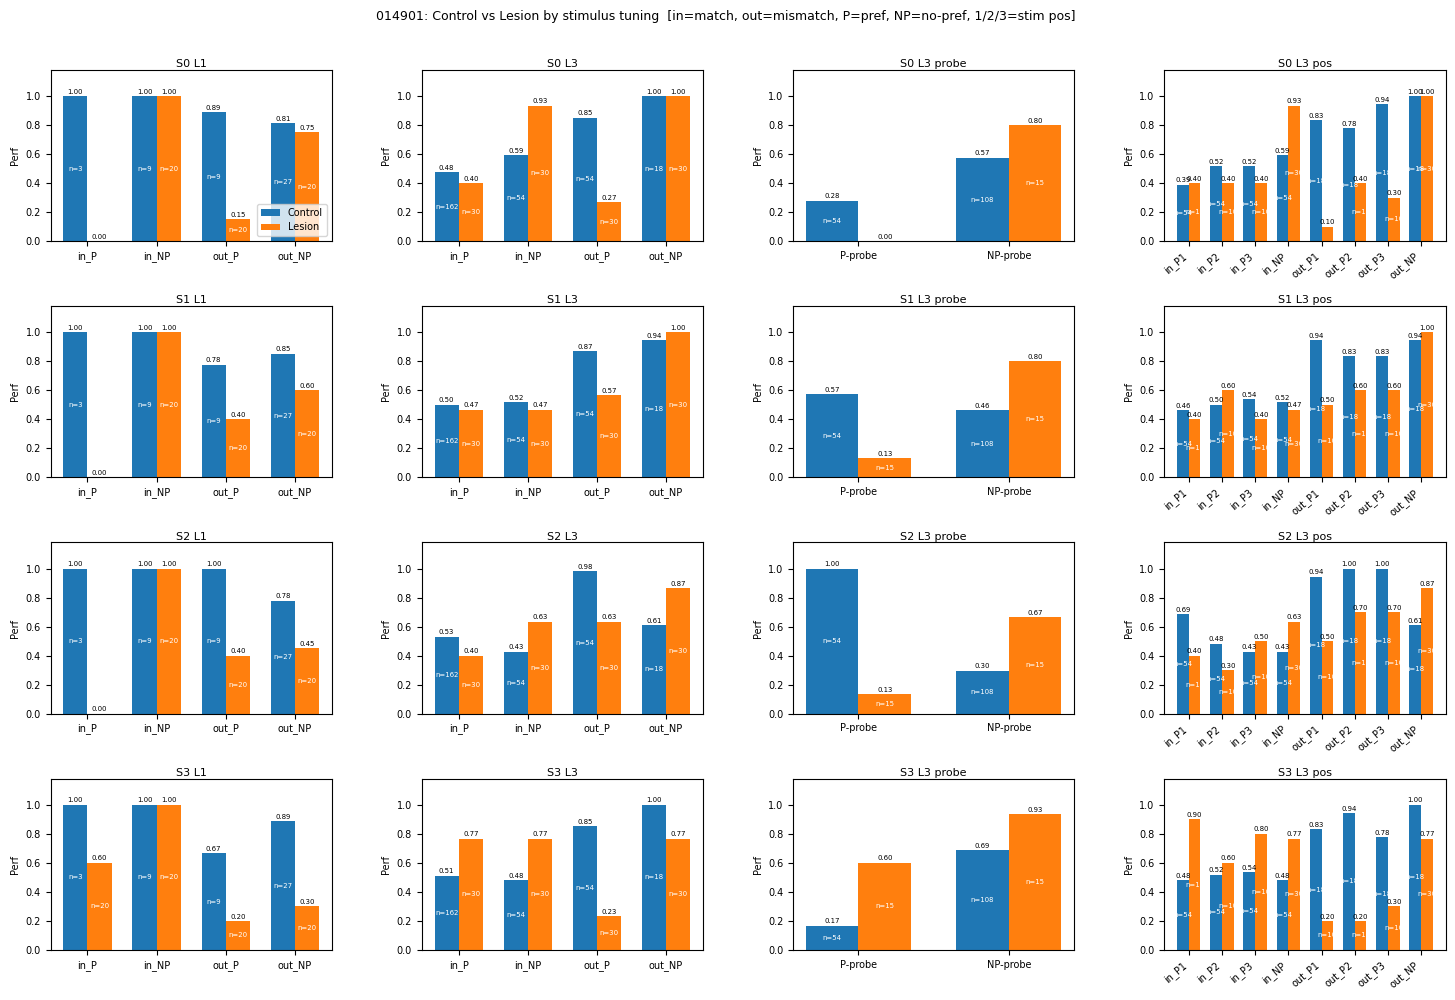

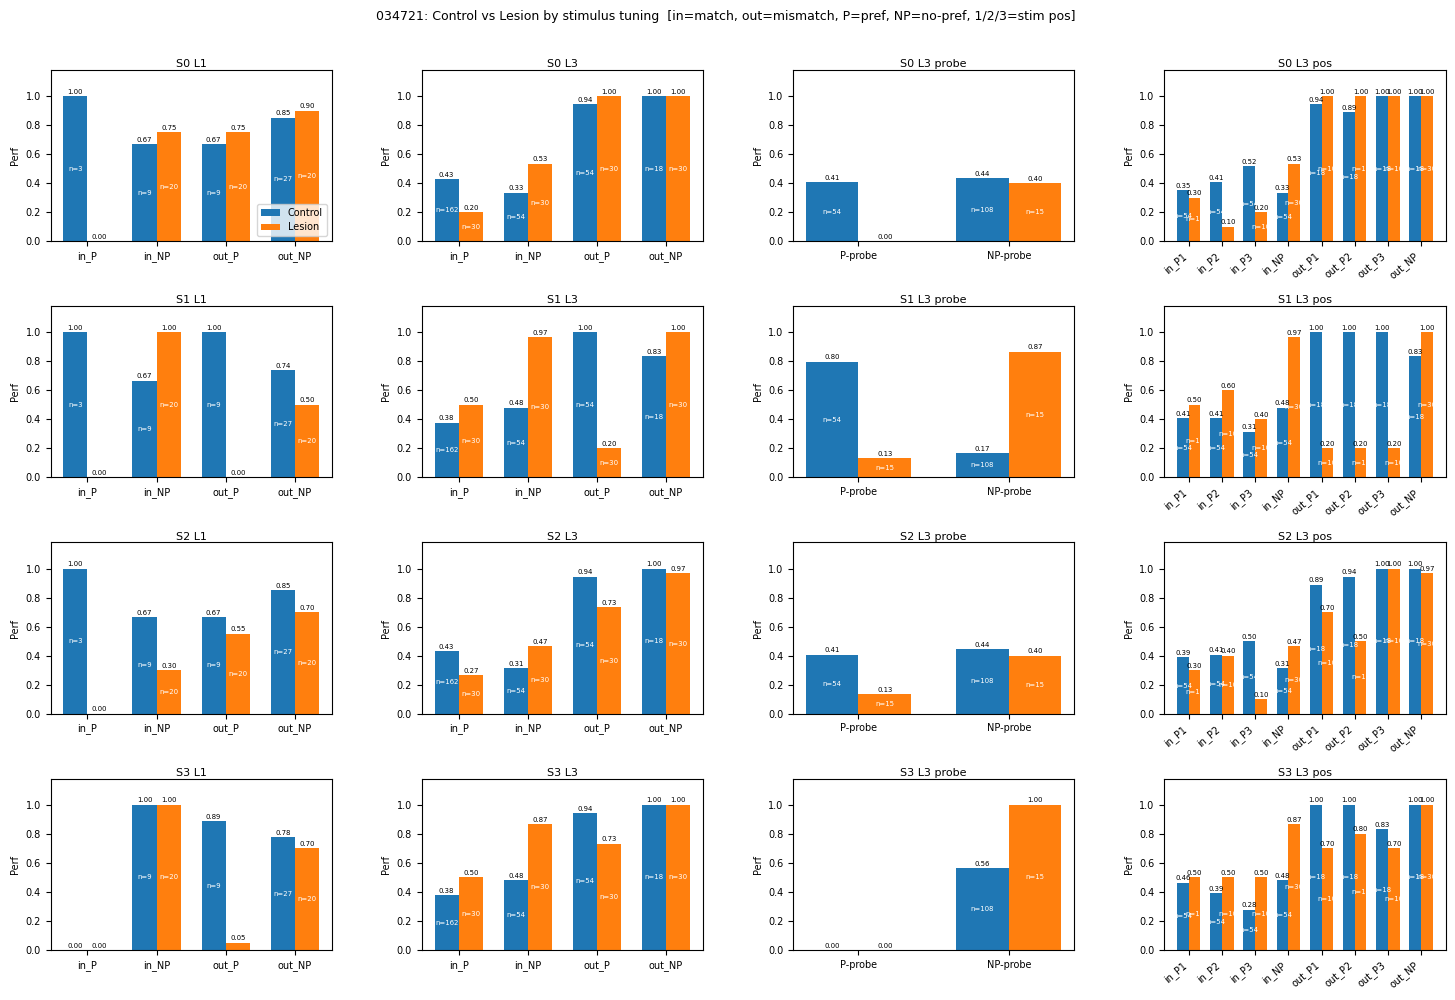

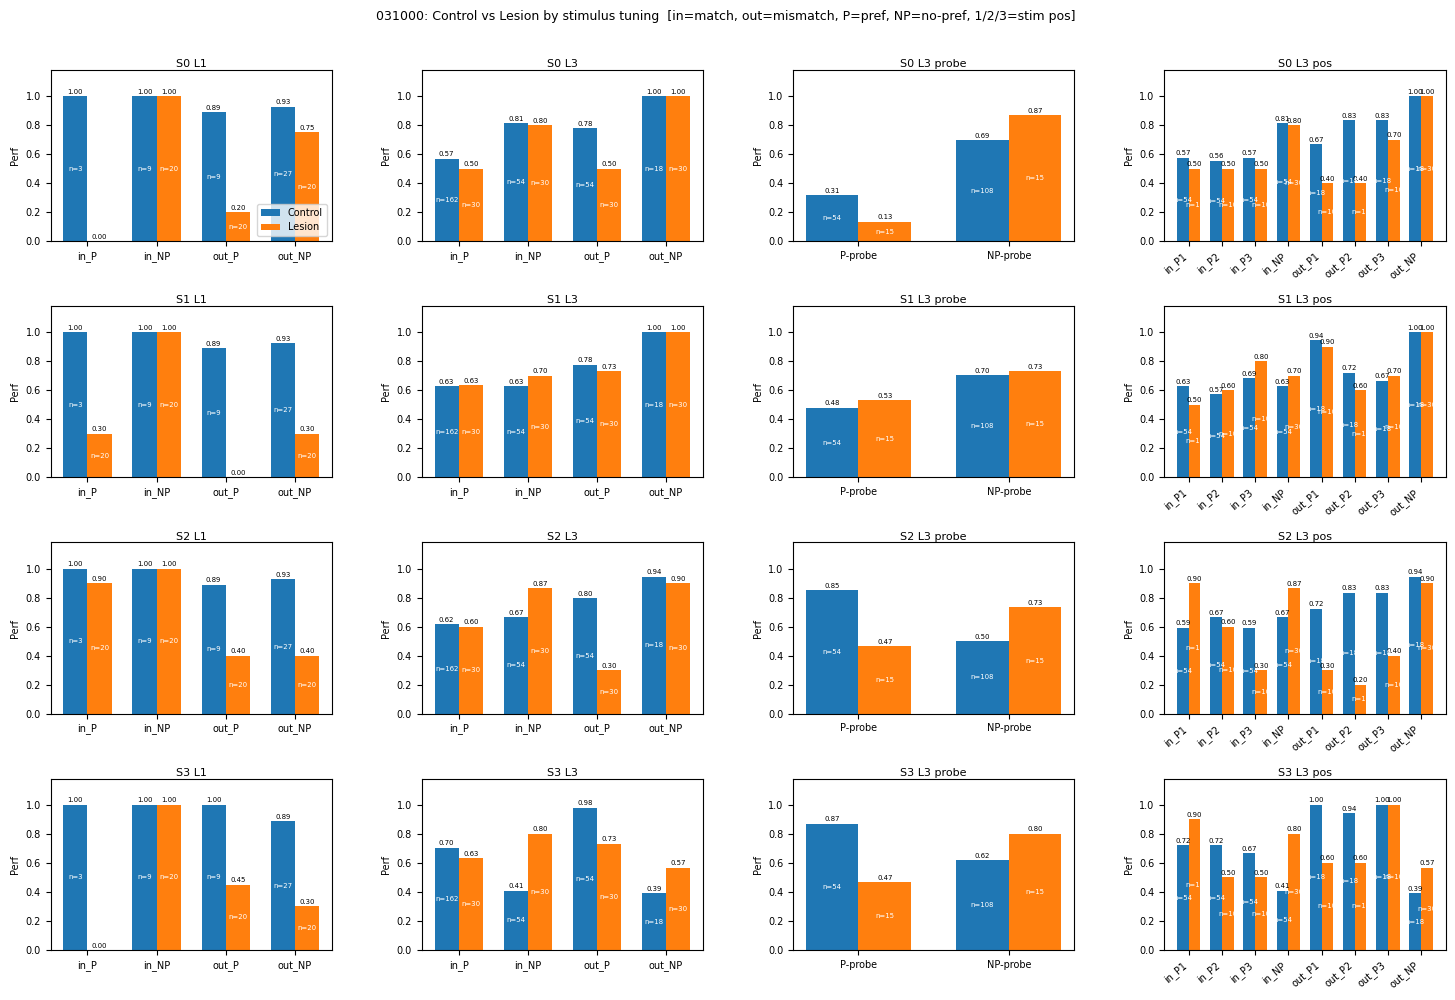

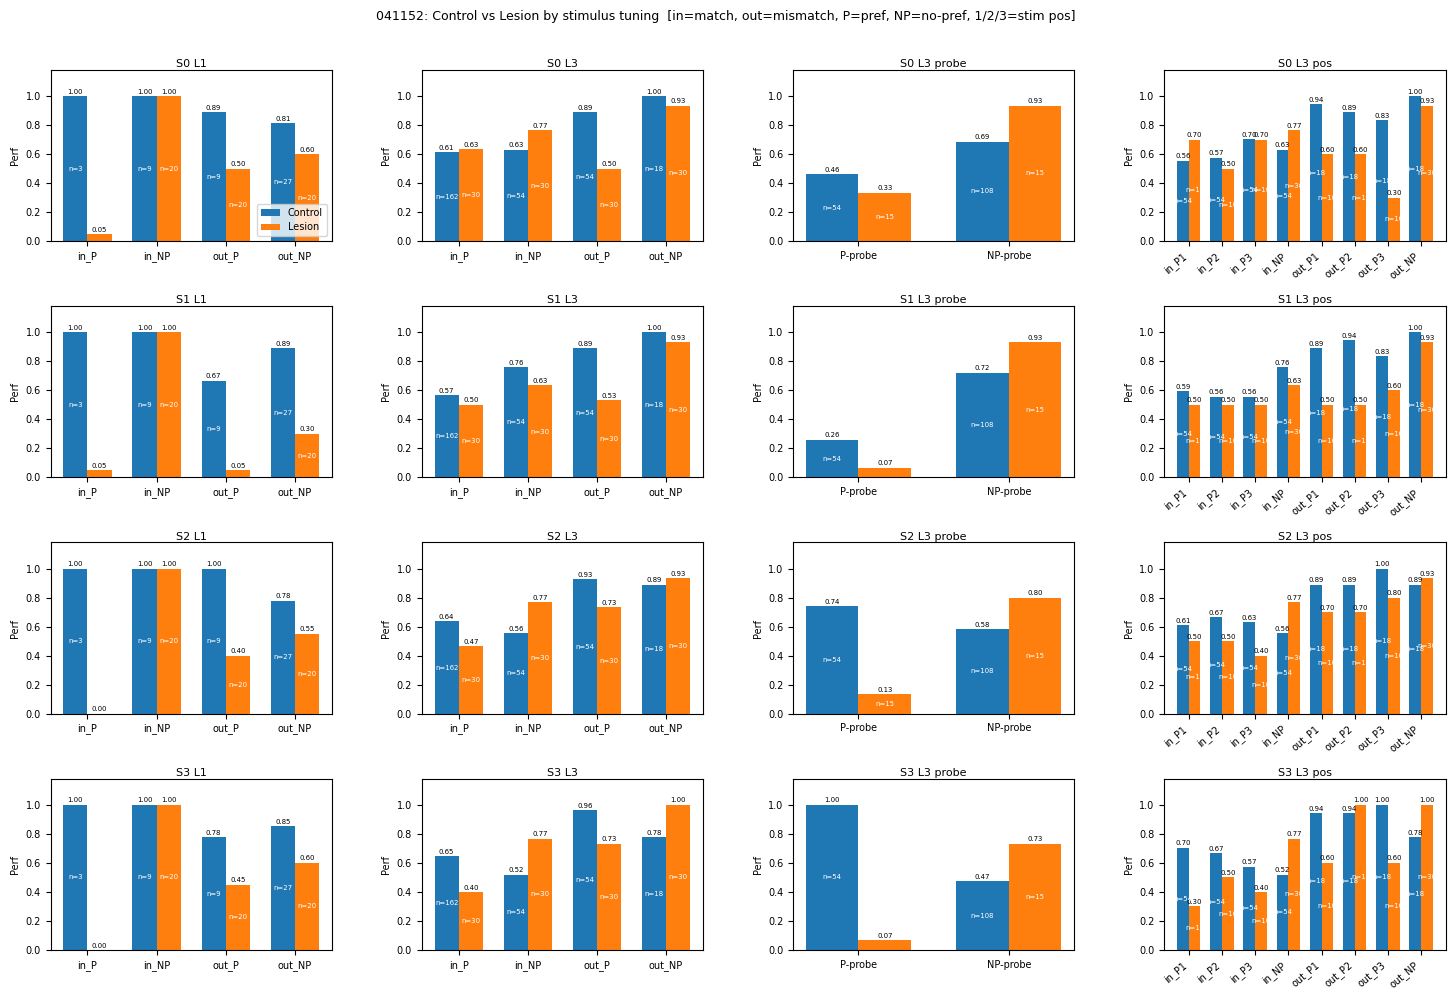

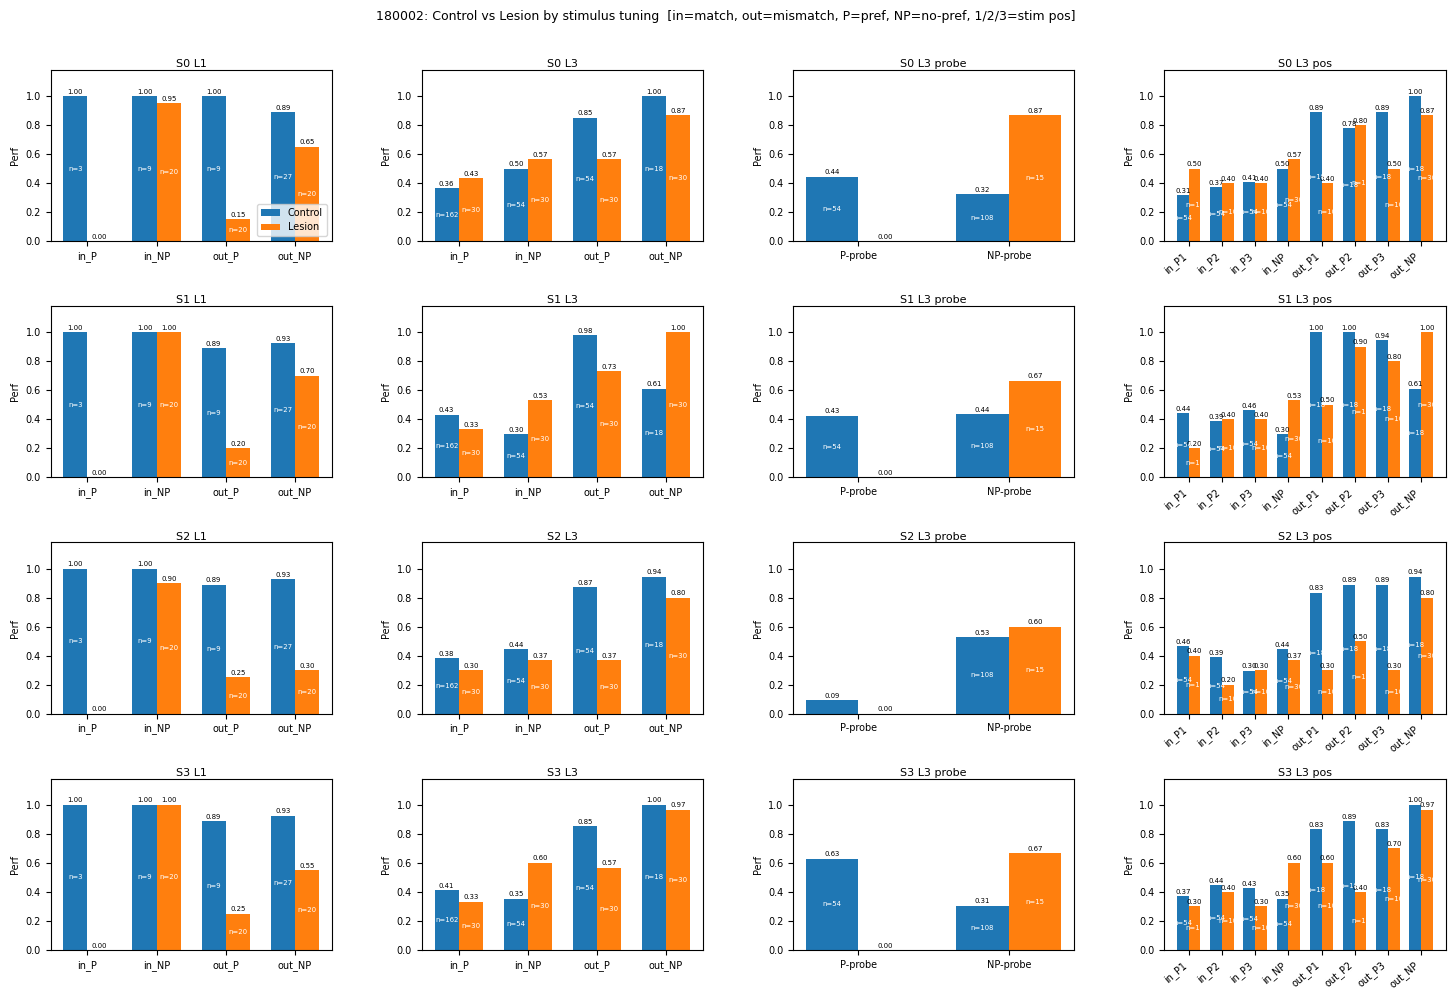

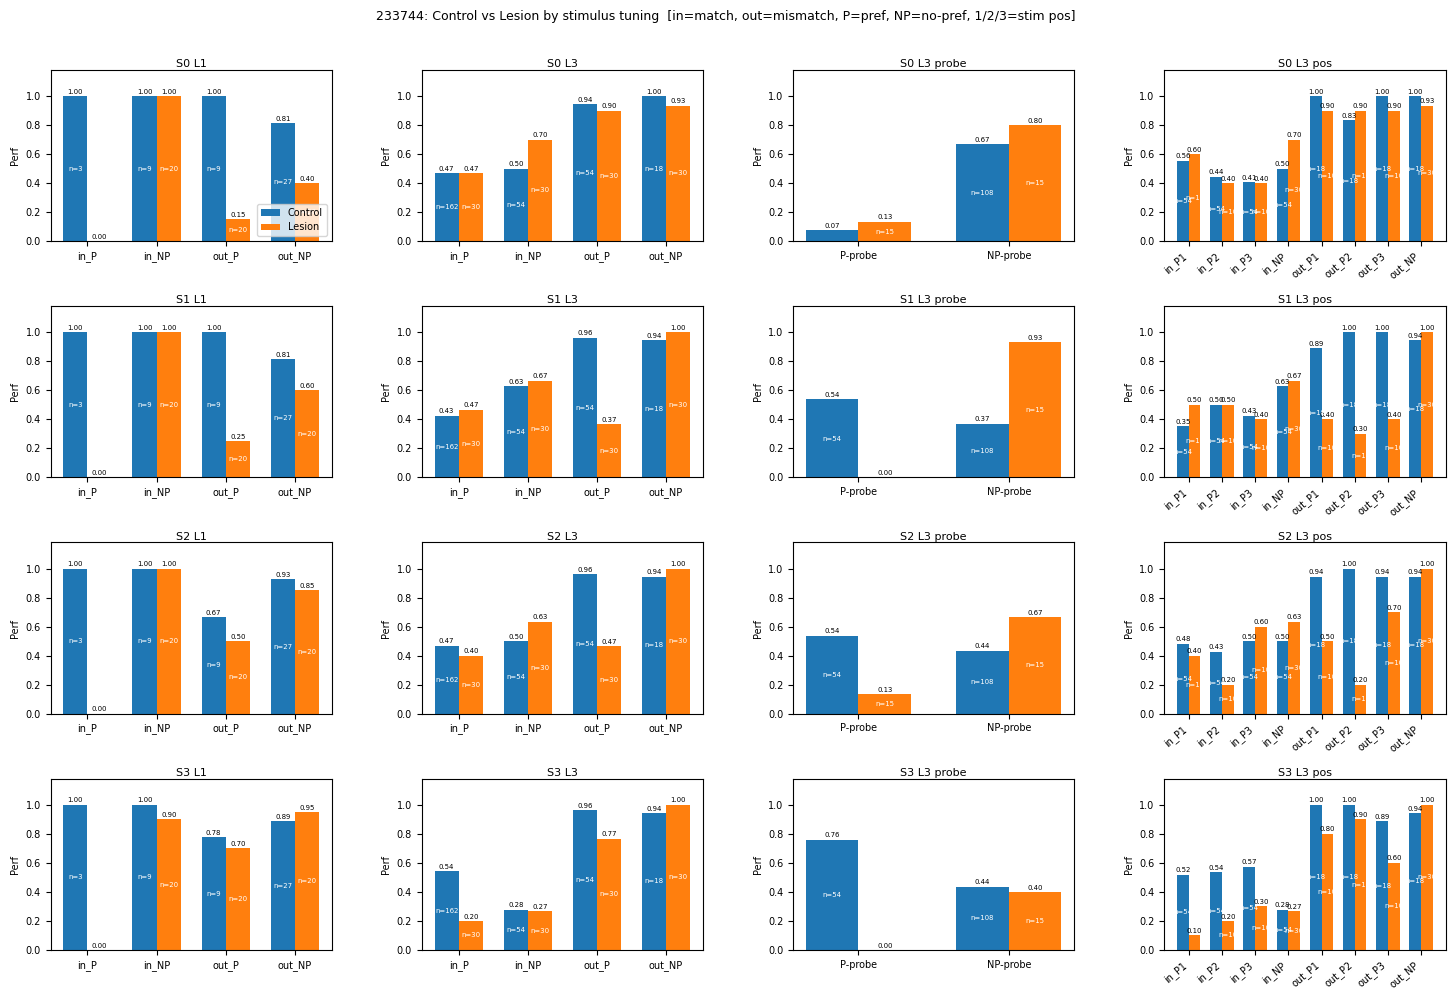

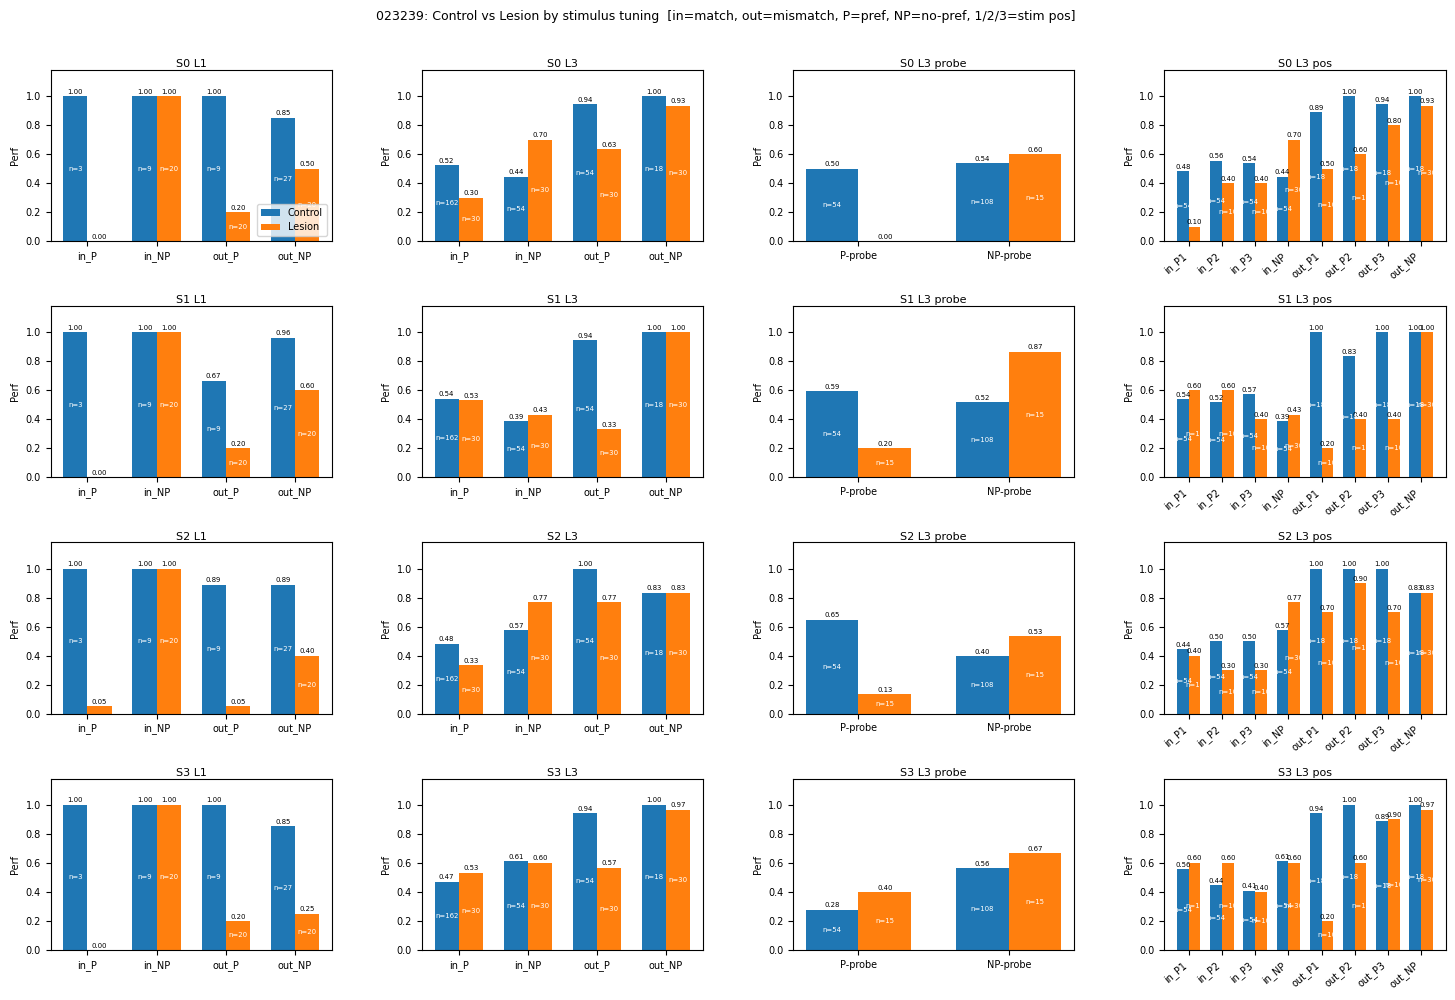

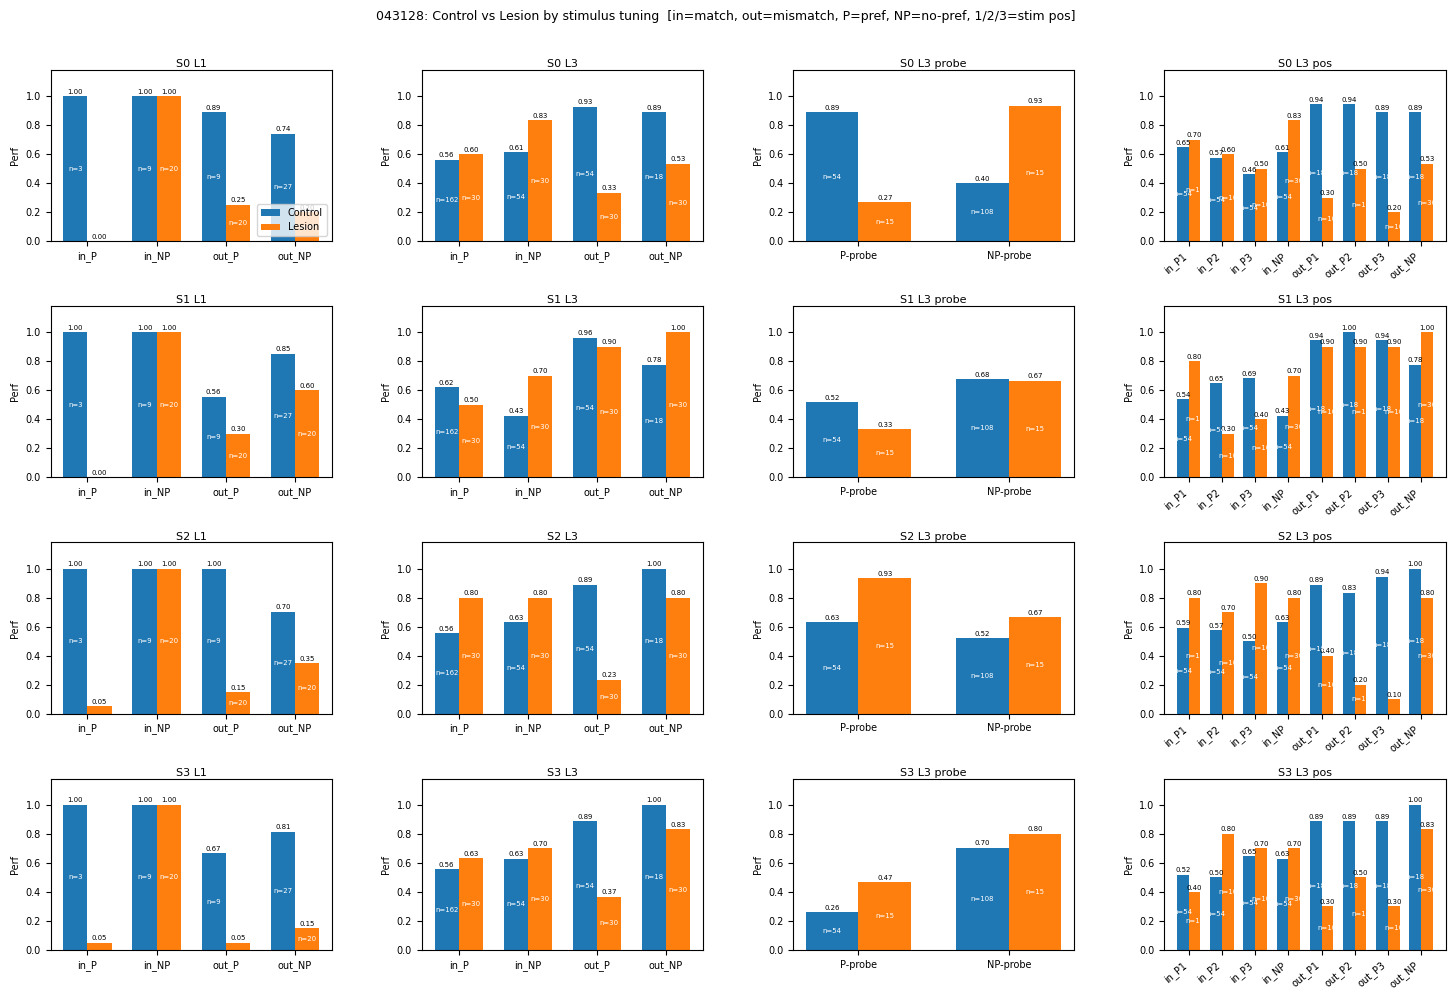

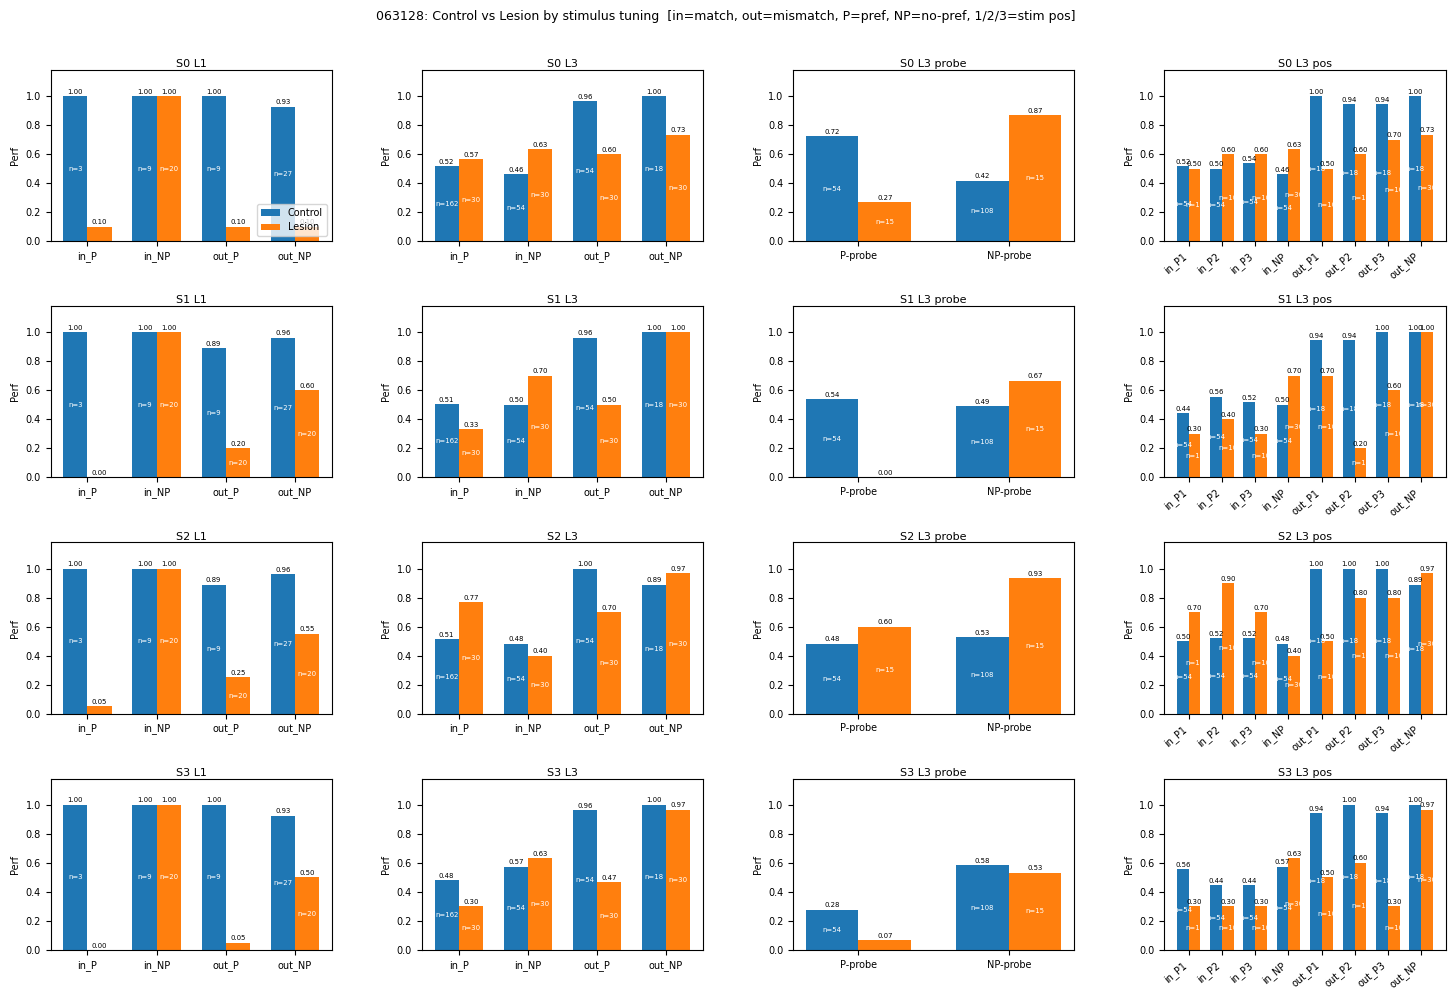

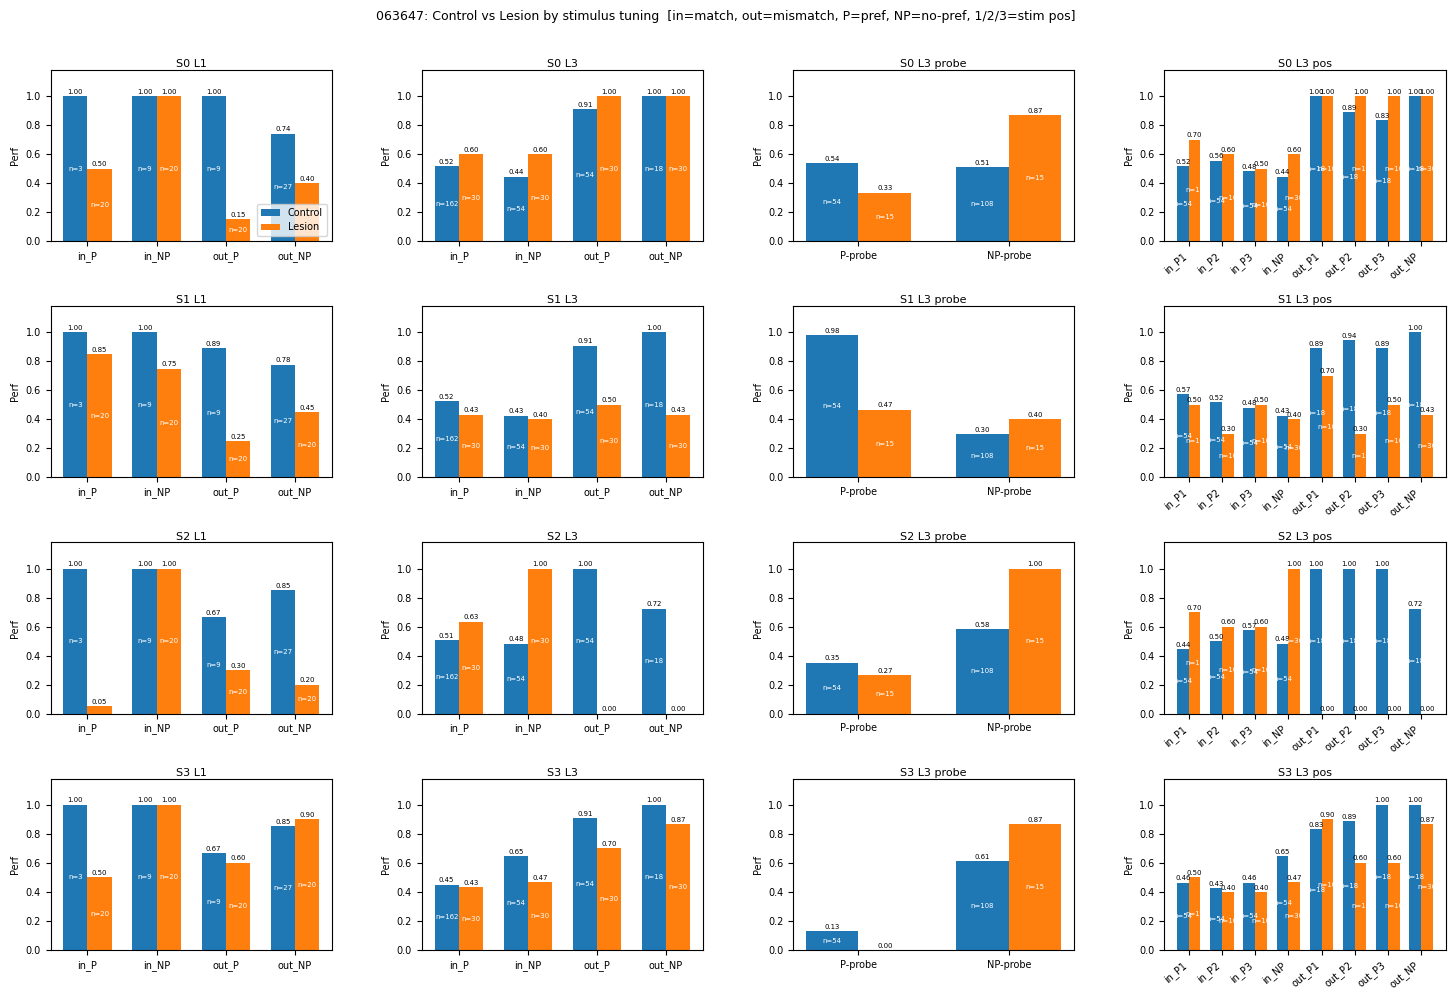

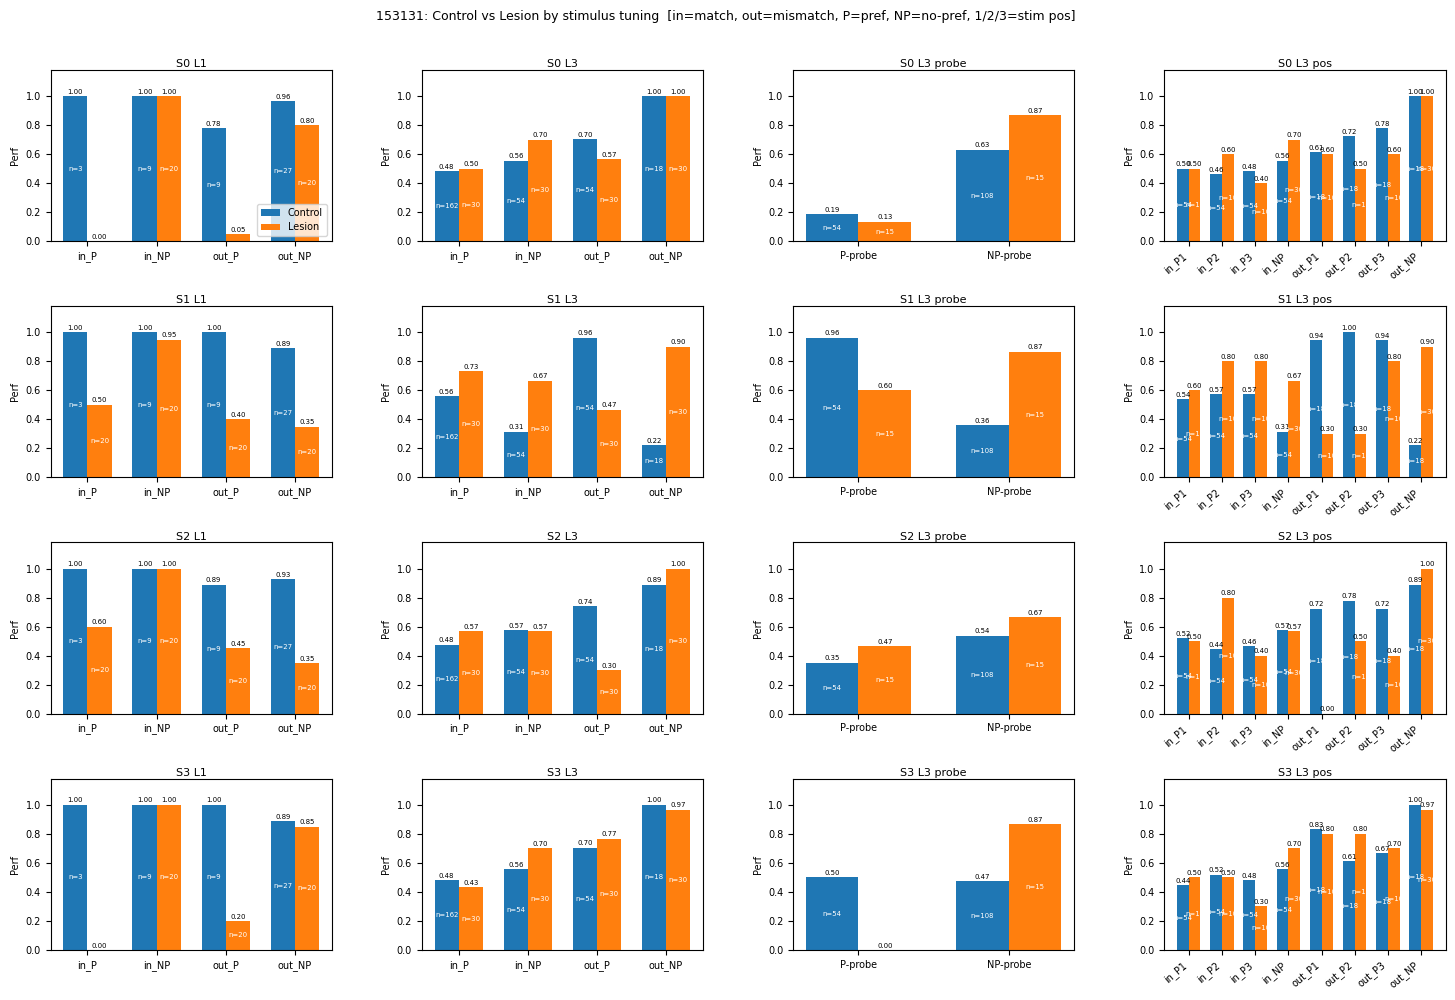

In [11]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

LOAD_LABELS = ['in_P', 'in_NP', 'out_P', 'out_NP']
PROBE_LABELS = ['P-probe', 'NP-probe']
POS_LABEL_MAP = {
    'Match\nPref1': 'in_P1', 'Match\nPref2': 'in_P2',
    'Match\nPref3': 'in_P3', 'Match\nNoPref': 'in_NP',
    'Mismatch\nPref1': 'out_P1', 'Mismatch\nPref2': 'out_P2',
    'Mismatch\nPref3': 'out_P3', 'Mismatch\nNoPref': 'out_NP',
}

FS = 7

for model_name in model_names:

    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_stim',
        all_models_dir=all_models_dir
    )

    # 4 horizontal strips, one per stimulus; each strip has 4 panels
    fig = plt.figure(figsize=(18, 10))
    gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.38, top=0.92, bottom=0.04)

    for stim_tuning in [0, 1, 2, 3]:
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[stim_tuning], wspace=0.32)
        row_axs  = [fig.add_subplot(gs_inner[0, c]) for c in range(4)]

        other_labels = f'precomputed_lesion_stim_stimpref_{stim_tuning}'
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

        # col 0: load=1
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=1)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=1)
        plot_grouped_bars(
            row_axs[0], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L1',
            fontsize=FS, show_legend=(stim_tuning == 0)
        )

        # col 1: load=3
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=3)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=3)
        plot_grouped_bars(
            row_axs[1], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L3',
            fontsize=FS
        )

        # col 2: load=3 match — pref as probe?
        ctrl_vals, ctrl_ns = get_pref_probe_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        lesion_vals, lesion_ns = get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning)
        plot_grouped_bars(
            row_axs[2], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            PROBE_LABELS, f'S{stim_tuning} L3 probe',
            fontsize=FS
        )

        # col 3: load=3 — pref stim position (8 bars)
        raw_labels, ctrl_vals, ctrl_ns = get_means_ns(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        _, lesion_vals, lesion_ns = get_means_ns(trial_labels, trial_perfs, stim_tuning)
        short_labels = [POS_LABEL_MAP.get(l, l) for l in raw_labels]
        plot_grouped_bars(
            row_axs[3], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            short_labels, f'S{stim_tuning} L3 pos',
            fontsize=FS, tick_rotation=40
        )

    fig.suptitle(
        f'{model_name[-6:]}: Control vs Lesion by stimulus tuning  '
        f'[in=match, out=mismatch, P=pref, NP=no-pref, 1/2/3=stim pos]',
        fontsize=9
    )
    plt.show()

# Lesion by 100%

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [7]:
for model_name in model_names:
    
    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]
    stim_tuning = stim1_stimtuning[stim_selective]
    
    unique_stims = np.unique(stim_tuning)
    for stim in unique_stims: # 0, 1, 2, 3
        neuron_idxs = stim_selective[stim_tuning == stim] # neuron indices for this specific stimulus
        u_all, trial_type_all = generate_stimset(pref=int(stim), settings=settings)

        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0,
            lesion_tag=f"stim_lesion0_stimpref_{stim:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

### analyze behavioral data

#### necessary functions

In [4]:
def get_stats(trial_labels, trial_perfs, stim_tuning, load):

    load_idxs = np.where(trial_labels[:,0] == load)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]
    mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]

    # Define "pref shown" based on load
    if load == 1:
        pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
    else:
        pref_shown = np.where(
            np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
        )[0]

    pref_not_shown = np.setdiff1d(
        np.arange(len(trial_labels)),
        pref_shown
    )

    load_match_idxs = np.intersect1d(load_idxs, match_idxs)
    load_mismatch_idxs = np.intersect1d(load_idxs, mismatch_idxs)

    vals = [
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_not_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_not_shown)])
    ]

    ns = [
        len(np.intersect1d(load_match_idxs, pref_shown)),
        len(np.intersect1d(load_match_idxs, pref_not_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_not_shown))
    ]

    return vals, ns

In [5]:
def get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning):

    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]

    pref_shown = np.where(
        np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
    )[0]

    pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
    pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

    match_pref = np.intersect1d(
        np.intersect1d(load3_idxs, match_idxs),
        pref_shown
    )

    match_pref_probe = np.intersect1d(match_pref, pref_probe)
    match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

    vals = [
        np.mean(trial_perfs[match_pref_probe]),
        np.mean(trial_perfs[match_pref_notprobe])
    ]

    ns = [
        len(match_pref_probe),
        len(match_pref_notprobe)
    ]

    return vals, ns

In [6]:
def get_means_ns(trial_labels, trial_perfs, stim_tuning):

    load3 = trial_labels[:,0] == 3
    match = trial_labels[:,1] == 1
    mismatch = trial_labels[:,1] == -1

    prefs = {
        'Pref1': trial_labels[:,2] == stim_tuning,
        'Pref2': trial_labels[:,3] == stim_tuning,
        'Pref3': trial_labels[:,4] == stim_tuning,
    }

    prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

    conds = {
        f'Match\n{name}': load3 & match & mask
        for name, mask in prefs.items()
    }

    conds.update({
        f'Mismatch\n{name}': load3 & mismatch & mask
        for name, mask in prefs.items()
    })

    means = [trial_perfs[m].mean() for m in conds.values()]
    ns = [m.sum() for m in conds.values()]

    return list(conds.keys()), means, ns

In [7]:
def plot_grouped_bars(ax, ctrl_vals, lesion_vals,
                      ctrl_ns, lesion_ns,
                      labels, title,
                      ylabel='Perf',
                      show_legend=False,
                      fontsize=9,
                      tick_rotation=0):

    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, ctrl_vals, width, color='tab:blue', label='Control')
    ax.bar(x + width/2, lesion_vals, width, color='tab:orange', label='Lesion')

    ha = 'right' if tick_rotation > 0 else 'center'
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize, rotation=tick_rotation, ha=ha)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1, pad=2)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_ylim(0, 1.18)

    # value labels on top of bars
    for xpos, val in zip(x - width/2, ctrl_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))
    for xpos, val in zip(x + width/2, lesion_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))

    # n= as white text centered inside bars
    for xpos, n, val in zip(x - width/2, ctrl_ns, ctrl_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')
    for xpos, n, val in zip(x + width/2, lesion_ns, lesion_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')

    if show_legend:
        ax.legend(fontsize=fontsize, loc='lower right')

#### analysis

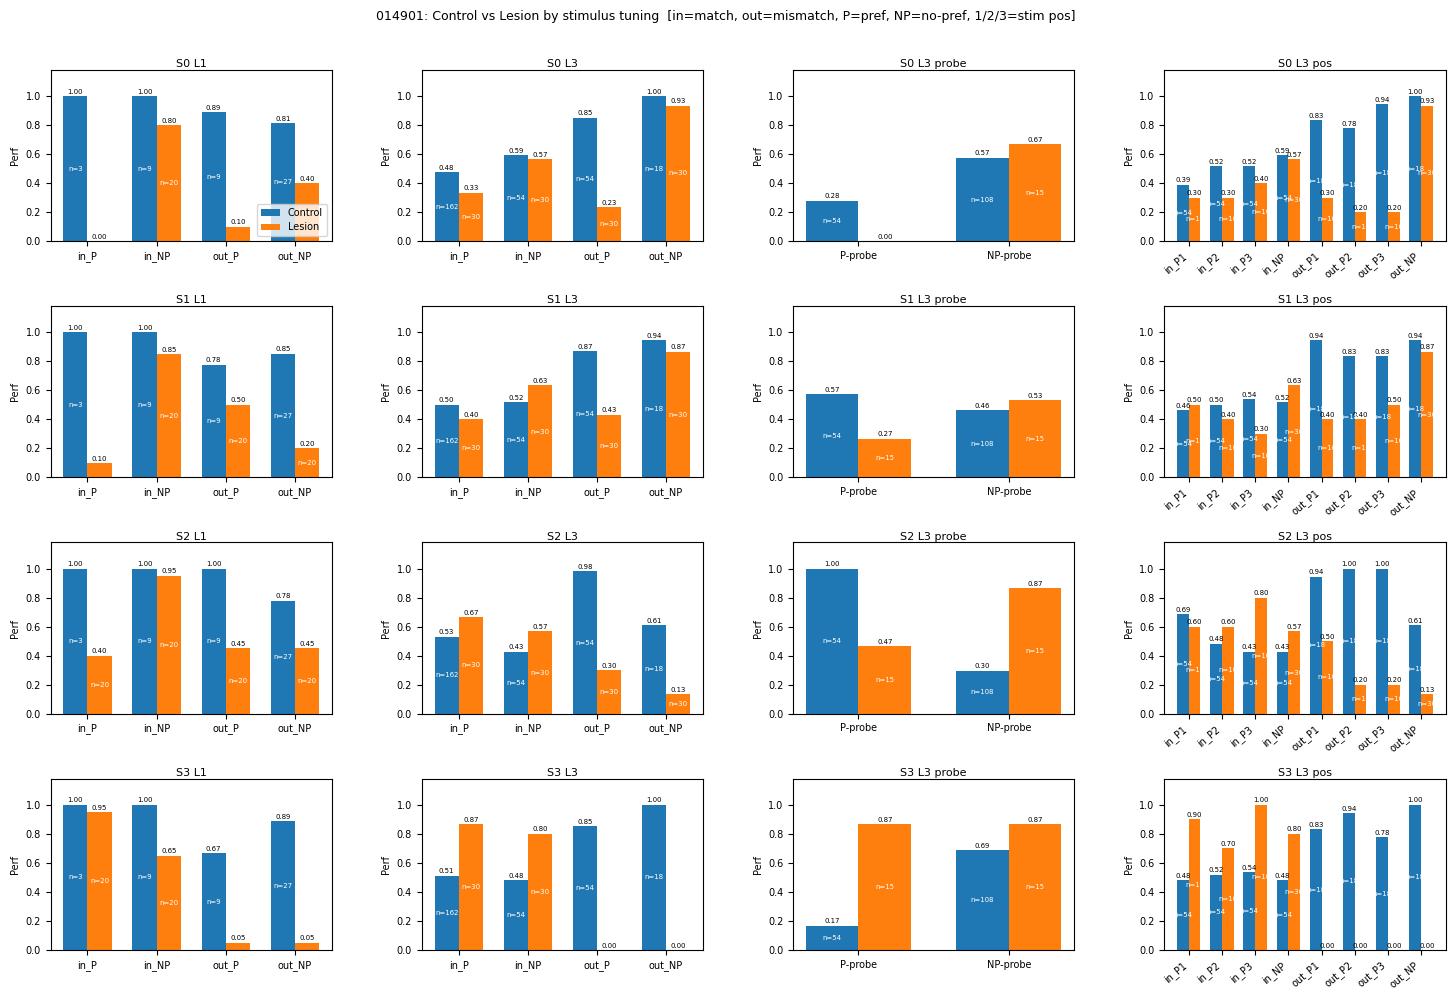

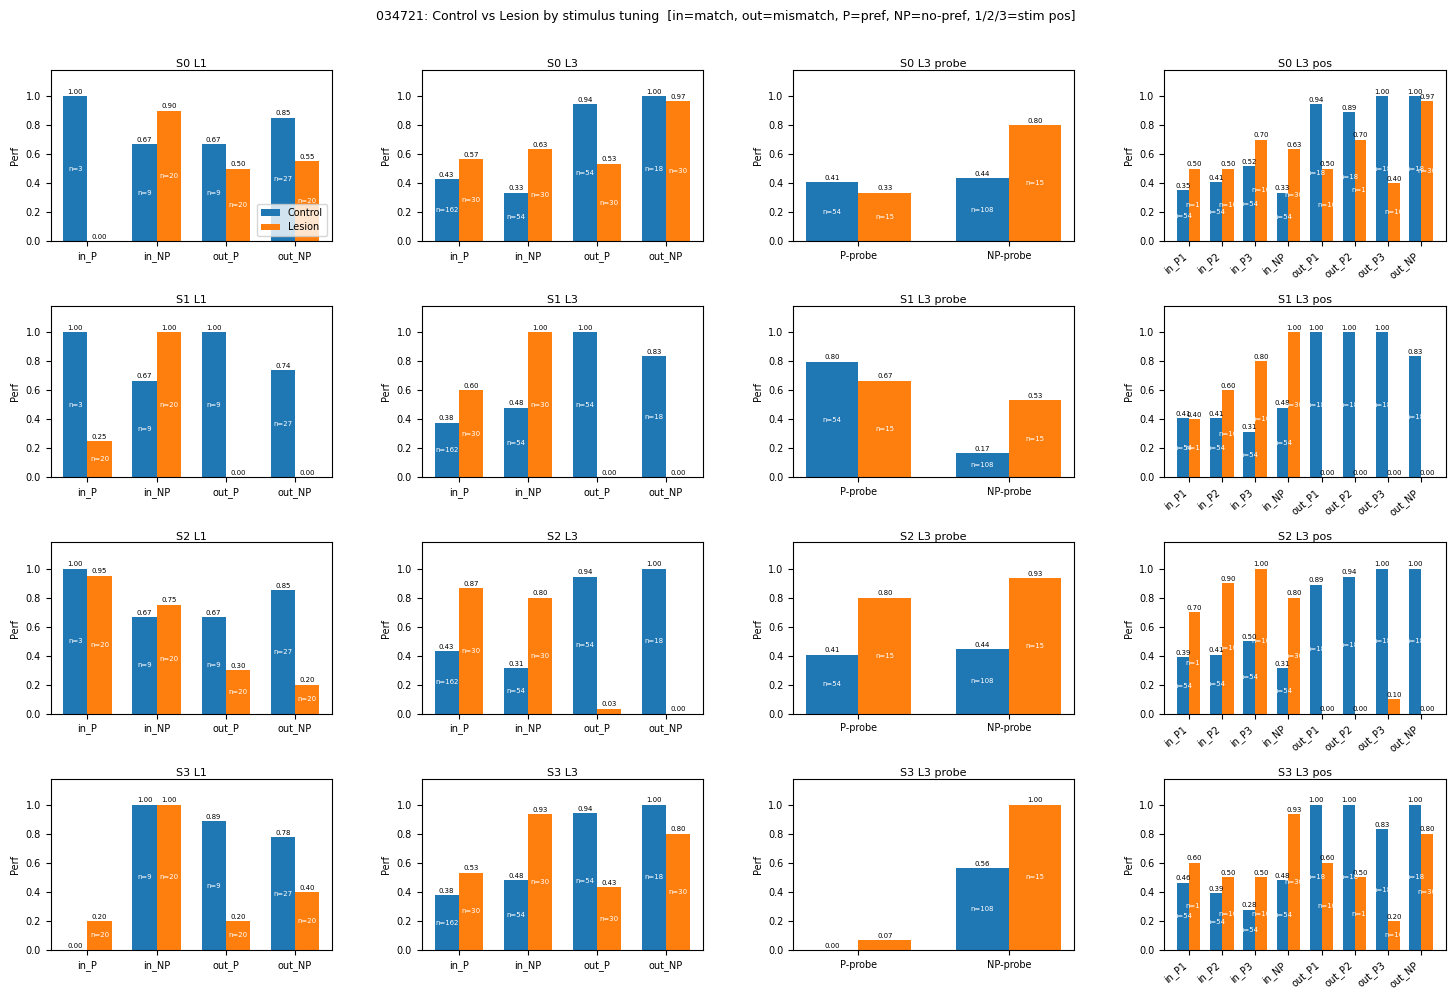

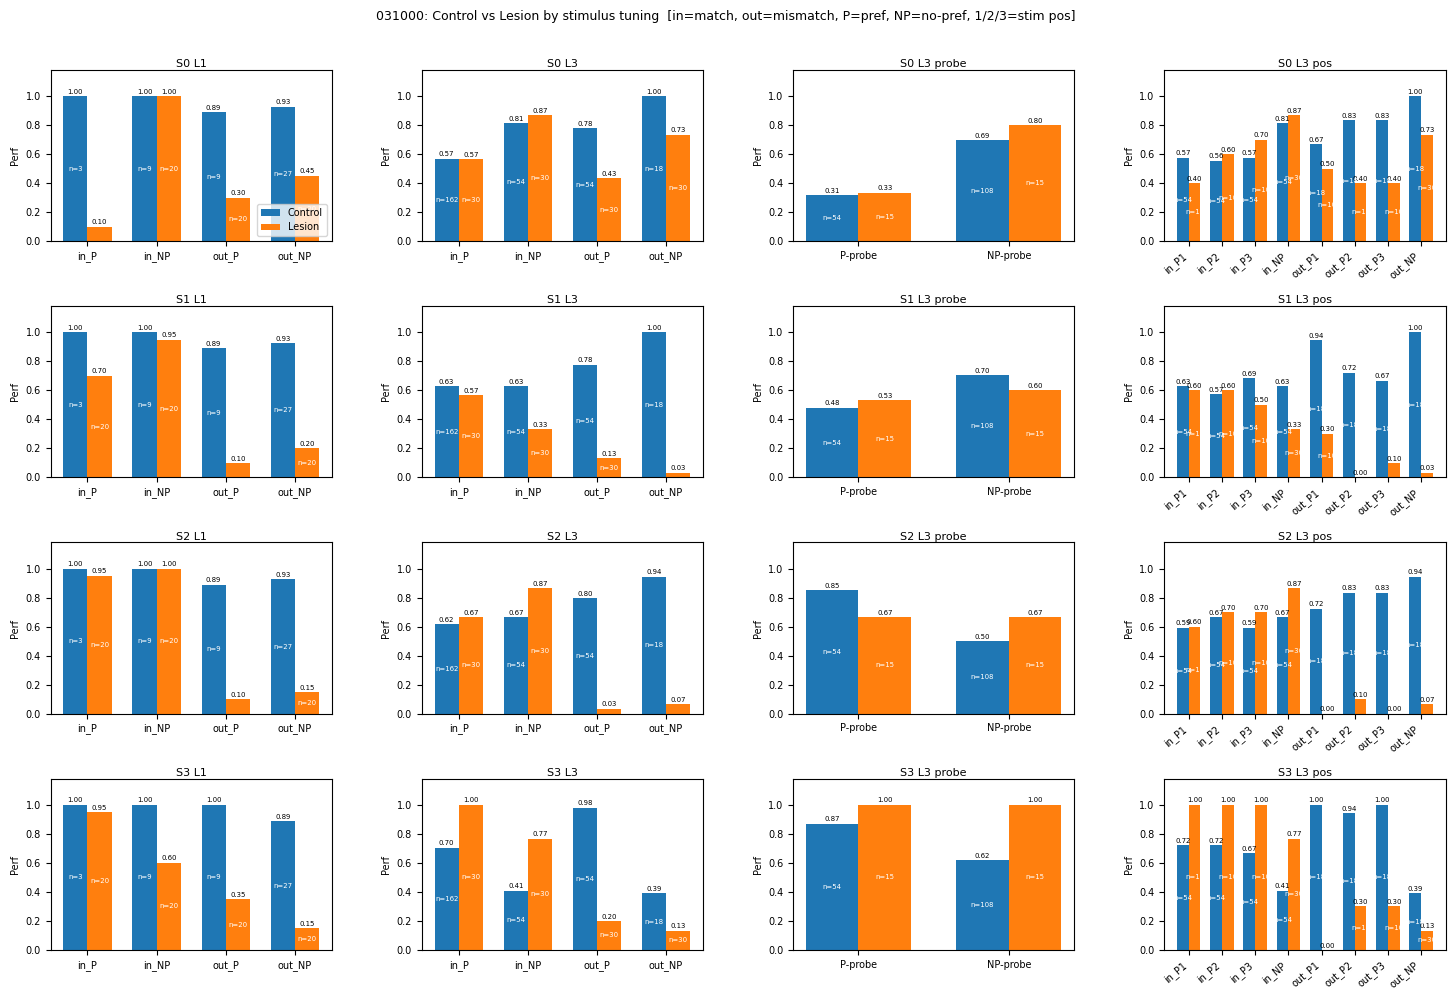

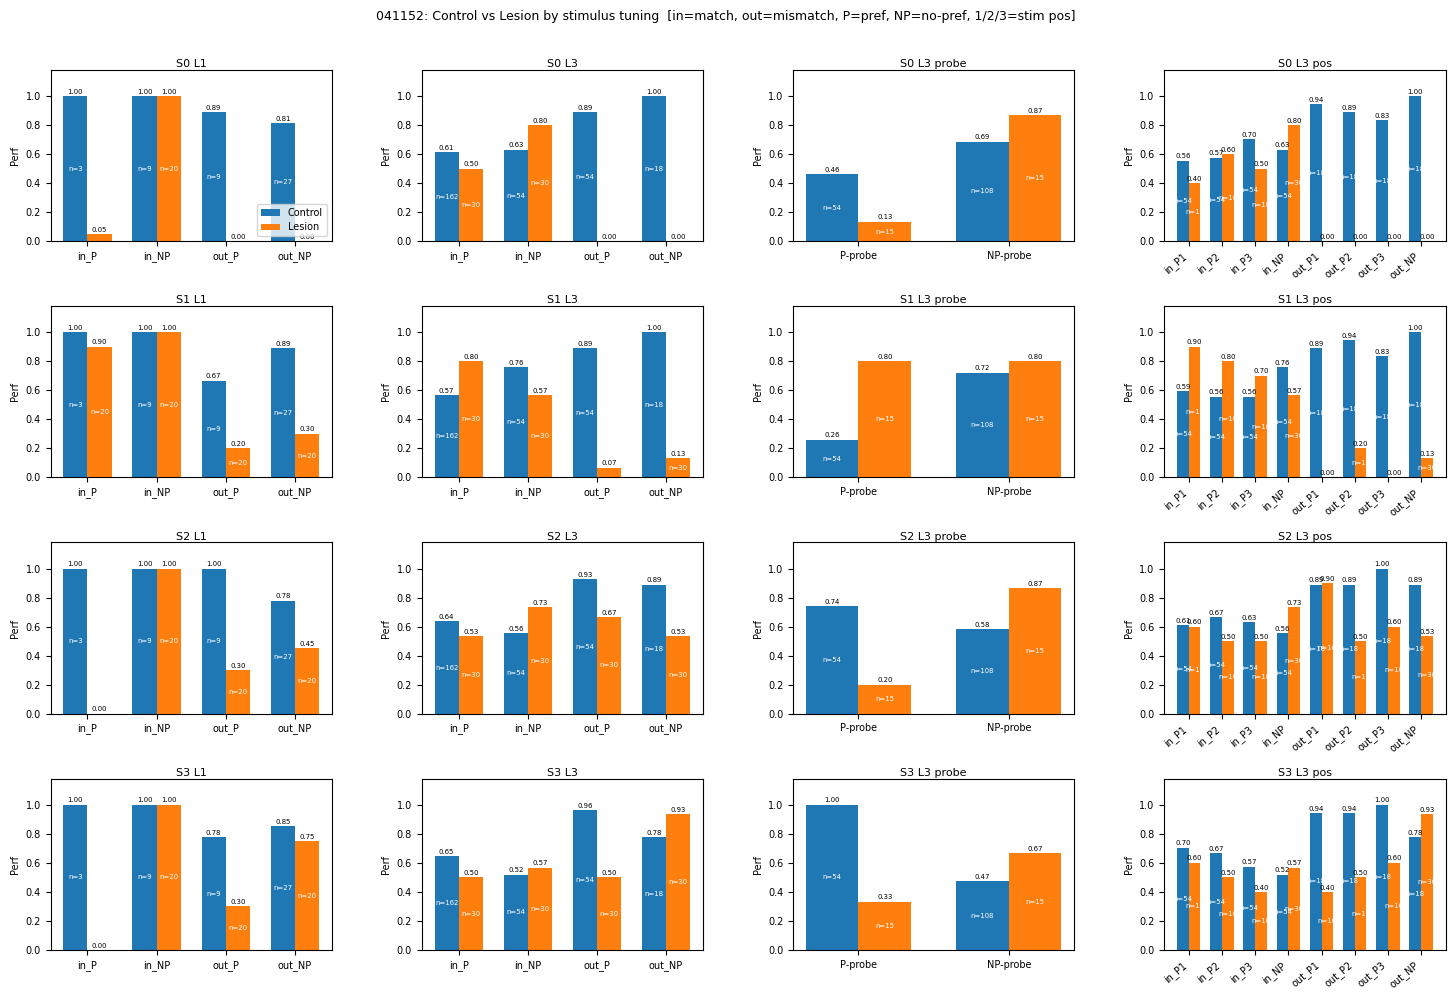

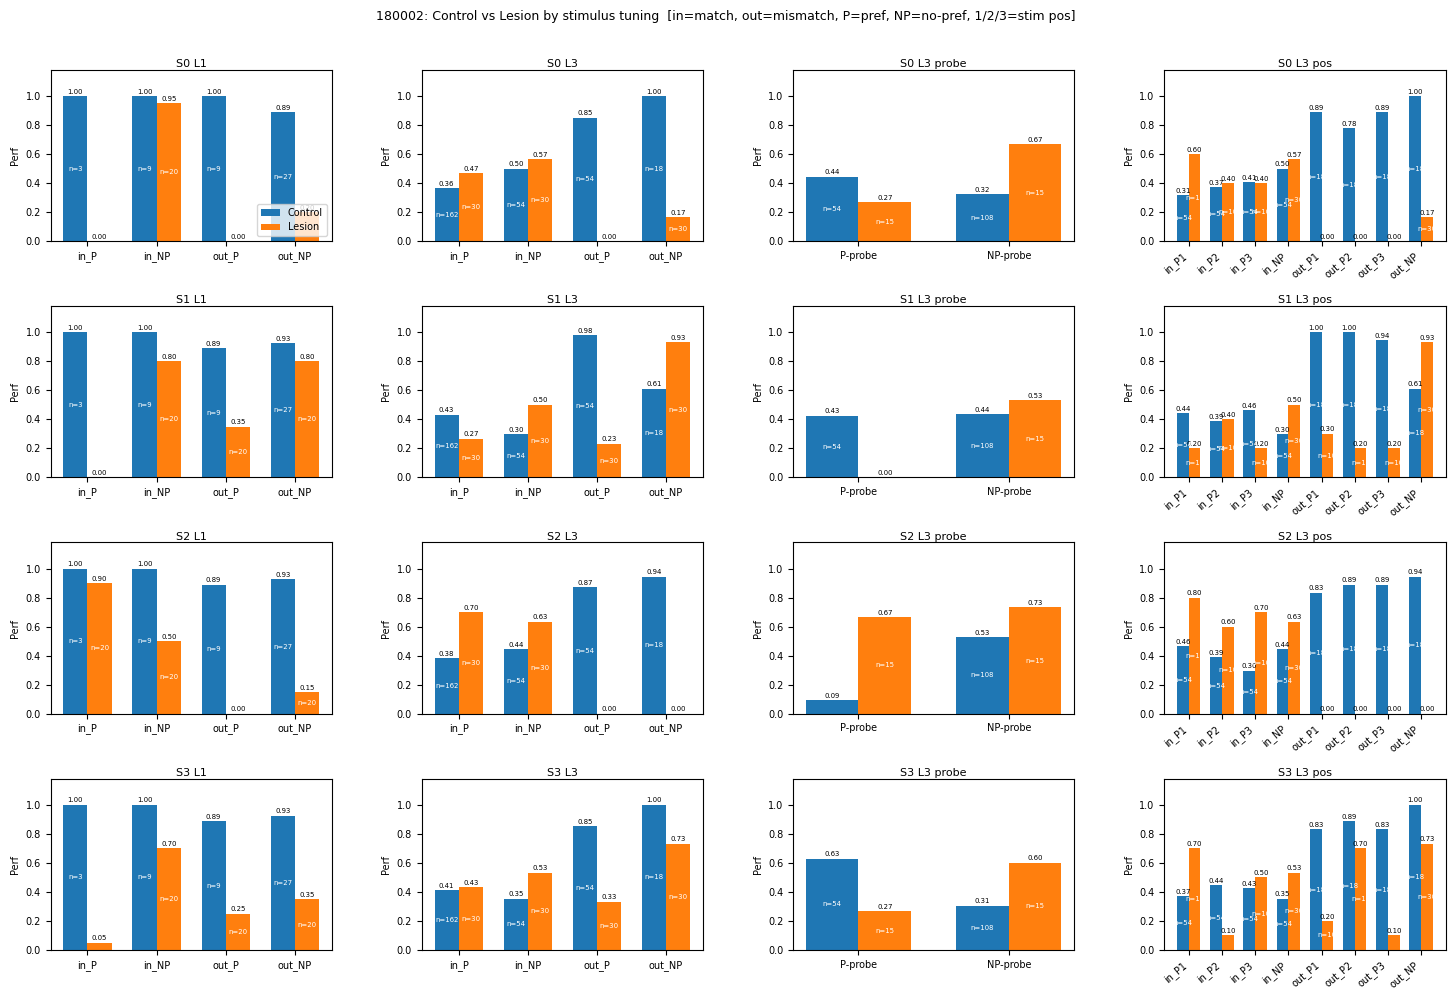

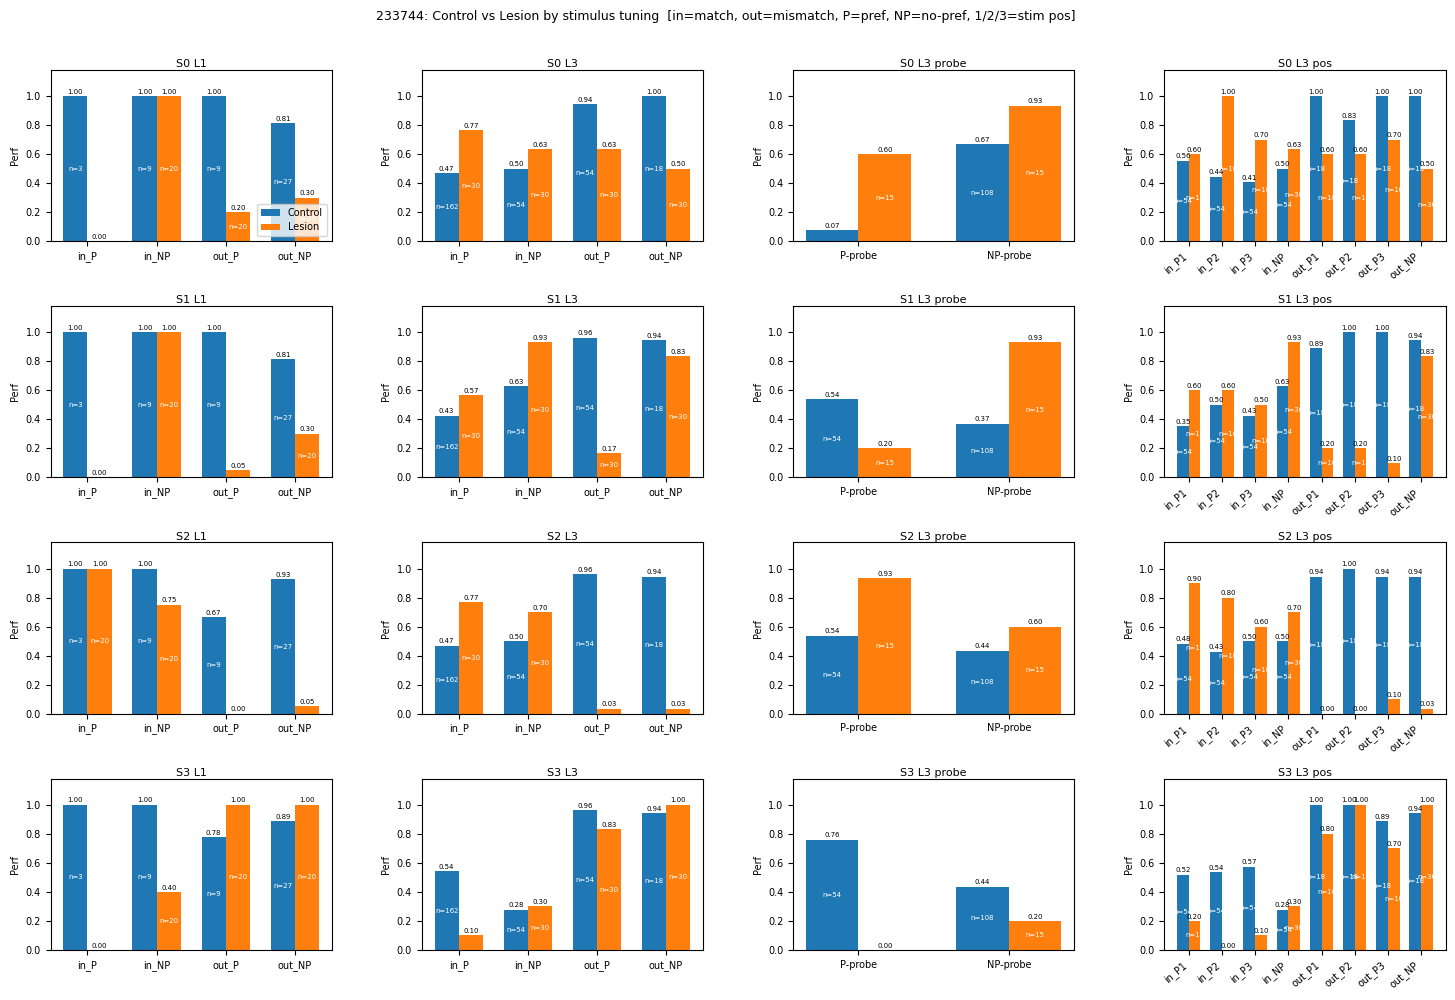

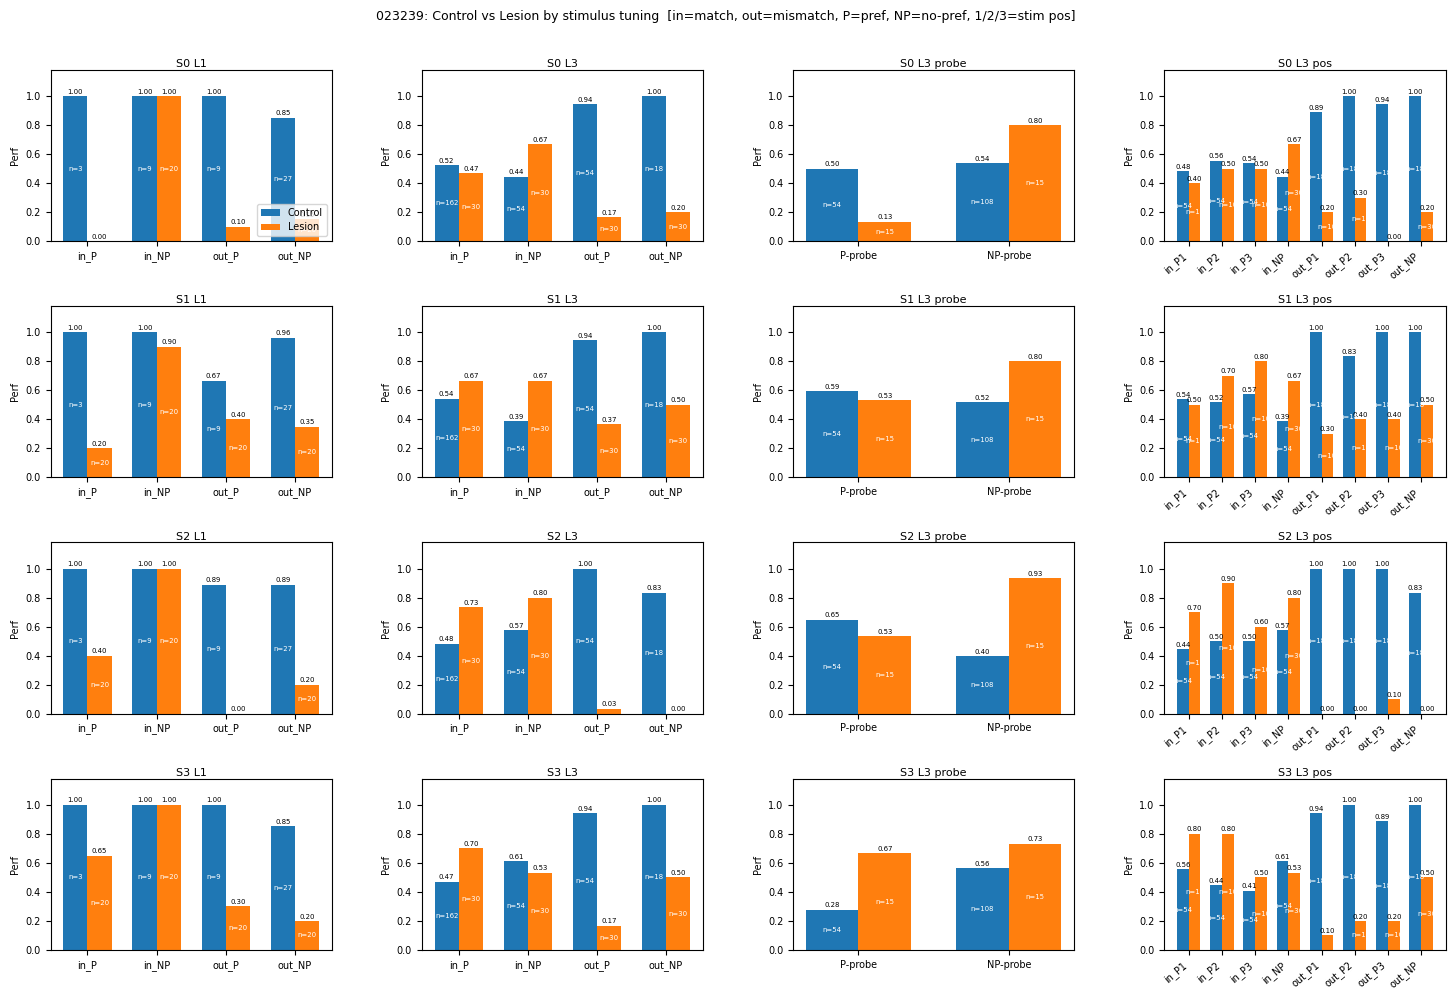

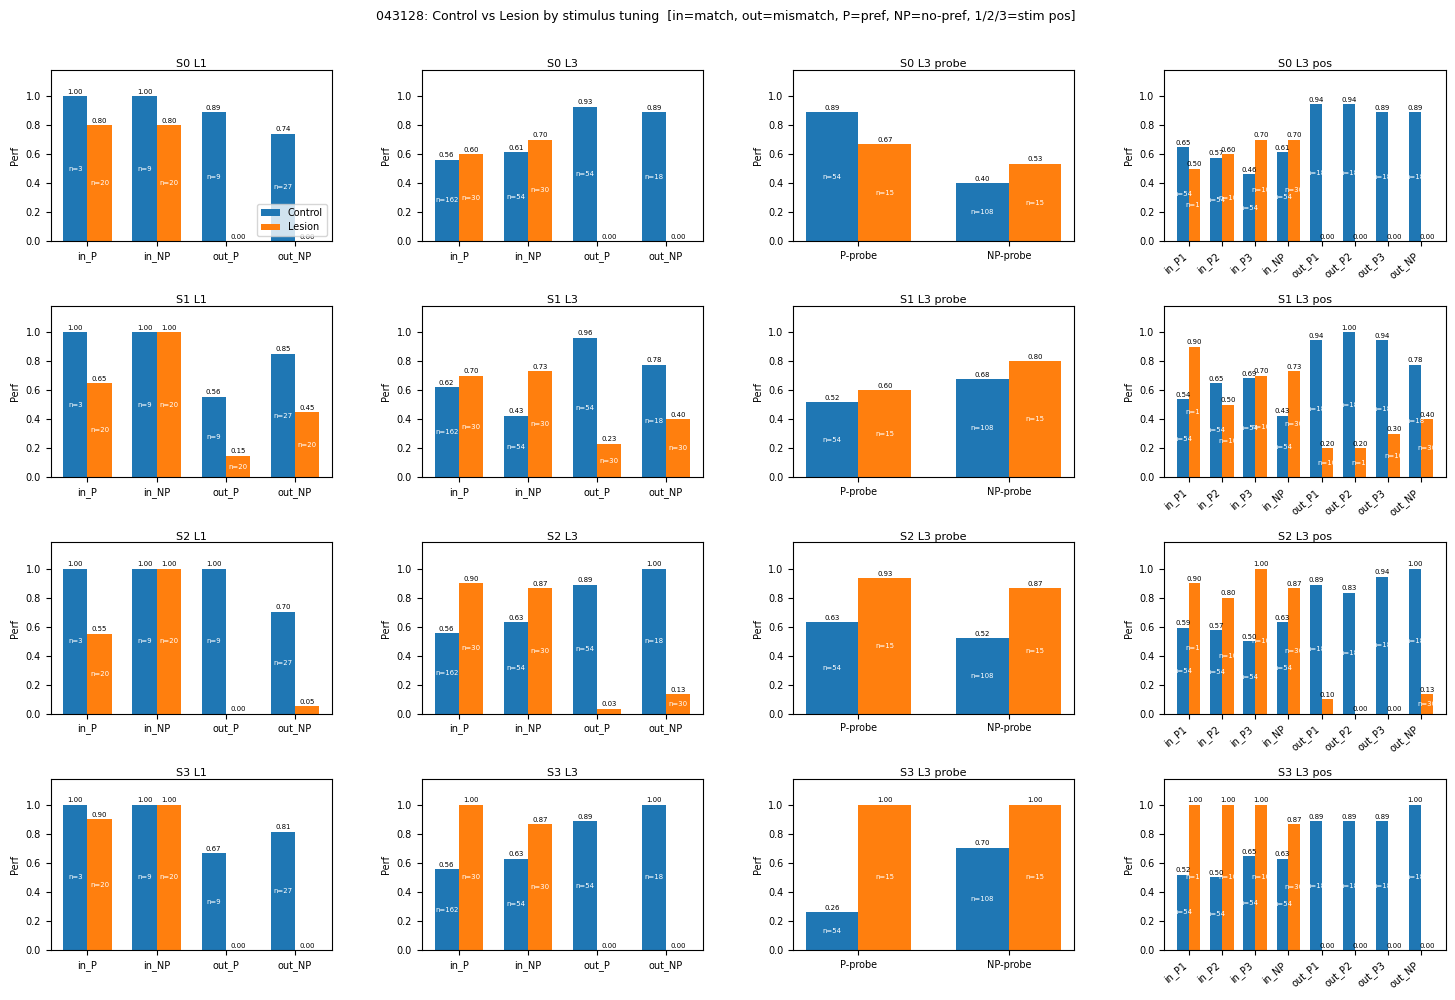

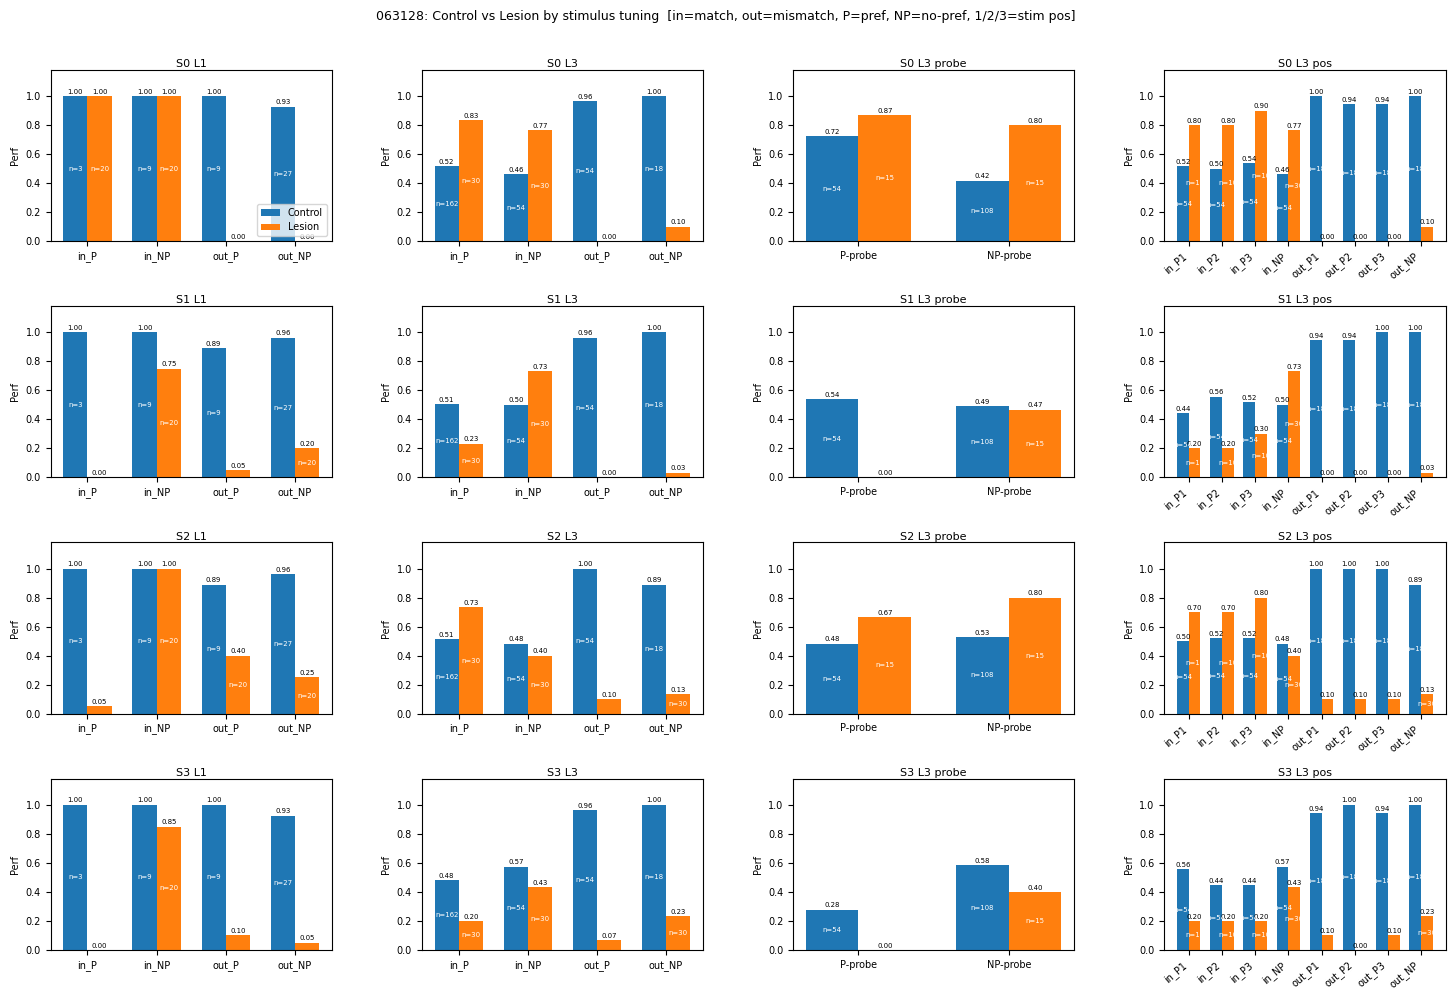

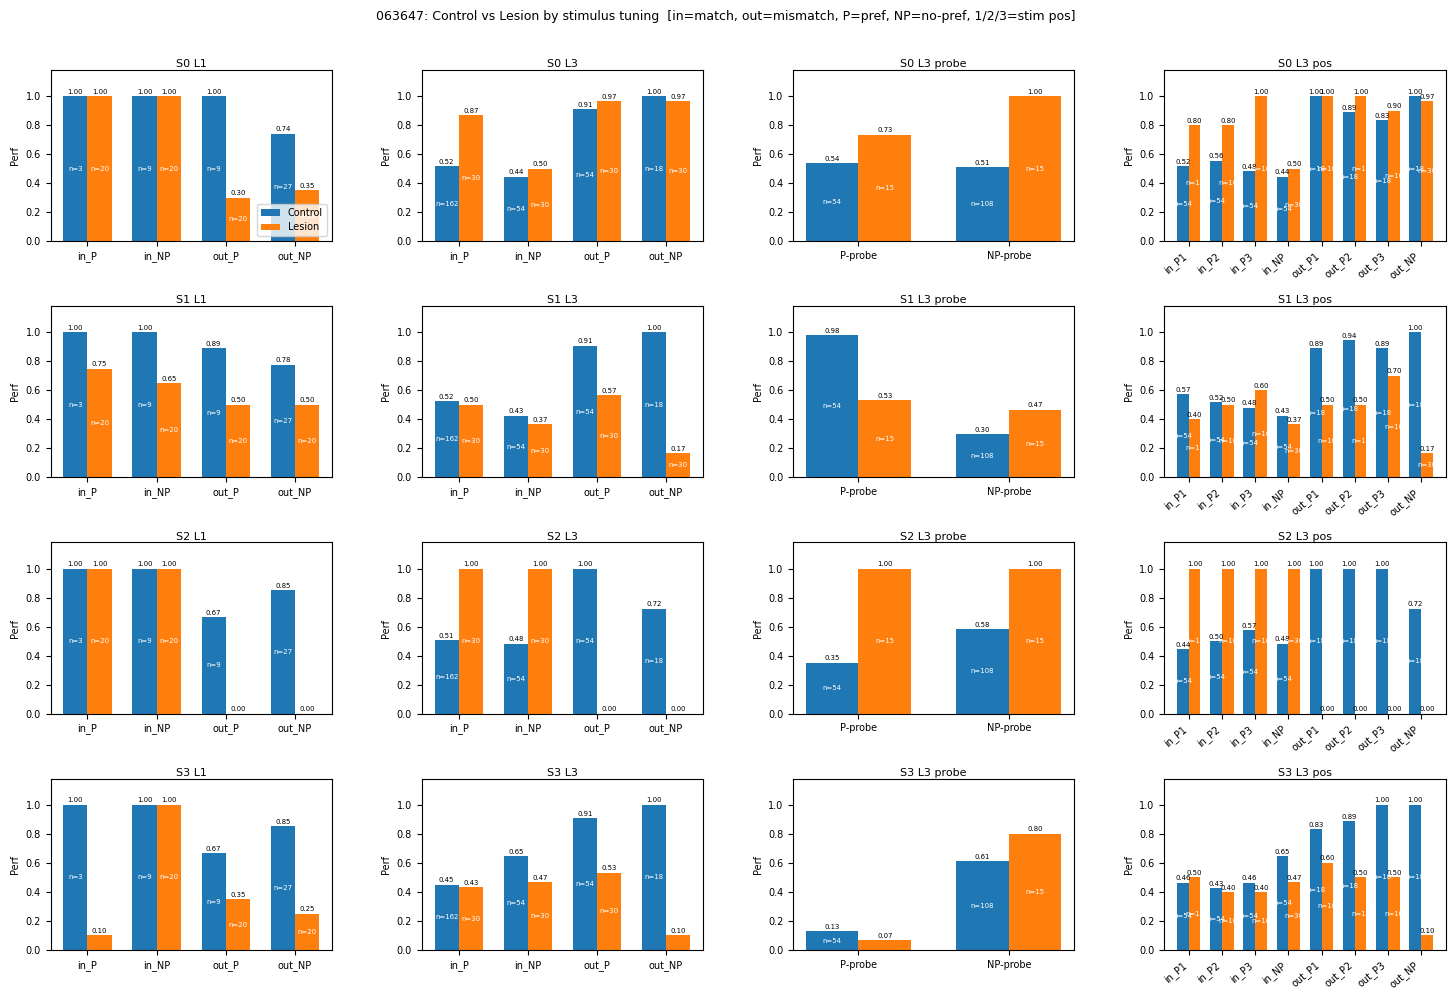

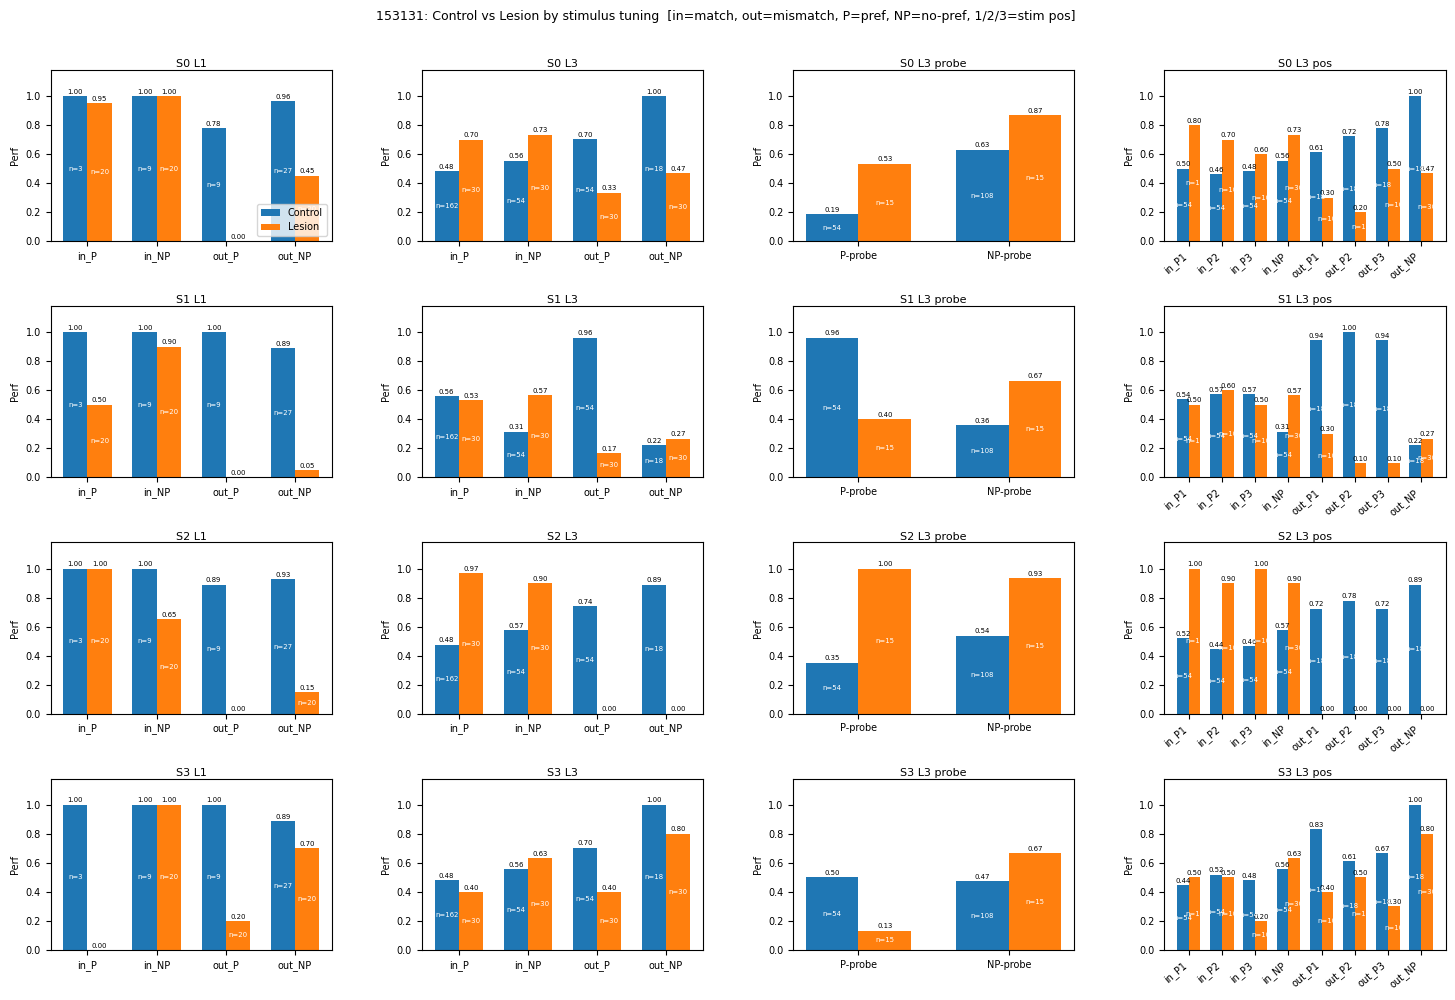

In [8]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

LOAD_LABELS = ['in_P', 'in_NP', 'out_P', 'out_NP']
PROBE_LABELS = ['P-probe', 'NP-probe']
POS_LABEL_MAP = {
    'Match\nPref1': 'in_P1', 'Match\nPref2': 'in_P2',
    'Match\nPref3': 'in_P3', 'Match\nNoPref': 'in_NP',
    'Mismatch\nPref1': 'out_P1', 'Mismatch\nPref2': 'out_P2',
    'Mismatch\nPref3': 'out_P3', 'Mismatch\nNoPref': 'out_NP',
}

FS = 7

for model_name in model_names:

    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_stim',
        all_models_dir=all_models_dir
    )

    # 4 horizontal strips, one per stimulus; each strip has 4 panels
    fig = plt.figure(figsize=(18, 10))
    gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.38, top=0.92, bottom=0.04)

    for stim_tuning in [0, 1, 2, 3]:
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[stim_tuning], wspace=0.32)
        row_axs  = [fig.add_subplot(gs_inner[0, c]) for c in range(4)]

        other_labels = f'precomputed_lesion_stim_lesion0_stimpref_{stim_tuning}'
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

        # col 0: load=1
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=1)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=1)
        plot_grouped_bars(
            row_axs[0], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L1',
            fontsize=FS, show_legend=(stim_tuning == 0)
        )

        # col 1: load=3
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=3)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=3)
        plot_grouped_bars(
            row_axs[1], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L3',
            fontsize=FS
        )

        # col 2: load=3 match — pref as probe?
        ctrl_vals, ctrl_ns = get_pref_probe_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        lesion_vals, lesion_ns = get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning)
        plot_grouped_bars(
            row_axs[2], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            PROBE_LABELS, f'S{stim_tuning} L3 probe',
            fontsize=FS
        )

        # col 3: load=3 — pref stim position (8 bars)
        raw_labels, ctrl_vals, ctrl_ns = get_means_ns(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        _, lesion_vals, lesion_ns = get_means_ns(trial_labels, trial_perfs, stim_tuning)
        short_labels = [POS_LABEL_MAP.get(l, l) for l in raw_labels]
        plot_grouped_bars(
            row_axs[3], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            short_labels, f'S{stim_tuning} L3 pos',
            fontsize=FS, tick_rotation=40
        )

    fig.suptitle(
        f'{model_name[-6:]}: Control vs Lesion by stimulus tuning  '
        f'[in=match, out=mismatch, P=pref, NP=no-pref, 1/2/3=stim pos]',
        fontsize=9
    )
    plt.show()